## Loading Data and Libraries &  Creating Target Variable

In [31]:
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
import numpy as np


### Load the Dataset

In [32]:
df = pd.read_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Master_Thesis/src/models/Merged_Price_pagerank_weighted_sentiment_new.csv')
df = df.rename(columns={'day_date': 'date'})

df = df.sort_values(by=['ticker_symbol', 'date'])

###  Preprocessing and Target Variable Encoding

In [33]:
df['tomorrow_open'] = df.groupby('ticker_symbol')['open_value'].shift(-1)

df = df[df['tomorrow_open'] != df['open_value']]  # Drop neutral cases

df['open_to_open_return'] = np.where(
    df['tomorrow_open'] > df['open_value'], 'up', 'down'
)
# Drop last row per ticker (no next day to compare)
df = df.dropna(subset=['tomorrow_open'])

df = df.drop(columns=['tomorrow_open'])

In [34]:
# # Calculate open_to_open_return
# df['tomorrow_open'] = df.groupby('ticker_symbol')['open_value'].shift(-1)
# df['open_to_open_return'] = np.where(
#     df['open_value'] > df['tomorrow_open'], 'down',
#     np.where(df['tomorrow_open'] > df['open_value'], 'up', 'neutral')
# )


# # Drop last row per ticker (no next day to compare)
# df = df.dropna(subset=['tomorrow_open'])

# df = df.drop(columns=['tomorrow_open'])


In [35]:
df.head()

,ticker_symbol,date,close_value,volume,open_value,high_value,low_value,sentiment_mapped_close_to_open,sentiment_mapped_open_to_close,weighted_sentiment_close_to_open,weighted_sentiment_open_to_close,open_to_open_return
1258,AAPL,2015-01-02,109.33,53143770,111.39,111.44,107.350,0.094872,-0.111111,-0.000191,-0.000020,down
1257,AAPL,2015-01-05,106.25,64210880,108.29,108.65,105.410,0.100224,0.009231,-0.000046,0.000036,down
1256,AAPL,2015-01-06,106.26,65682250,106.54,107.43,104.630,-0.005807,-0.055556,-0.000048,-0.000011,up
1255,AAPL,2015-01-07,107.75,39983350,107.20,108.20,106.695,0.028571,-0.007481,0.000023,-0.000108,up
1254,AAPL,2015-01-08,111.89,59168760,109.23,112.15,108.700,0.064830,-0.071588,-0.000006,-0.000048,up


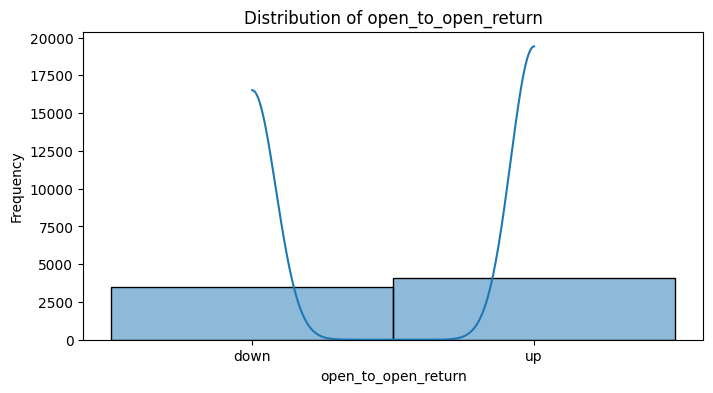

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['open_to_open_return'], bins=50, kde=True)
plt.title('Distribution of open_to_open_return')
plt.xlabel('open_to_open_return')
plt.ylabel('Frequency')
plt.show()


In [37]:
print(df['open_to_open_return'].value_counts(normalize=True))


open_to_open_return
up      0.540372
down    0.459628
Name: proportion, dtype: float64


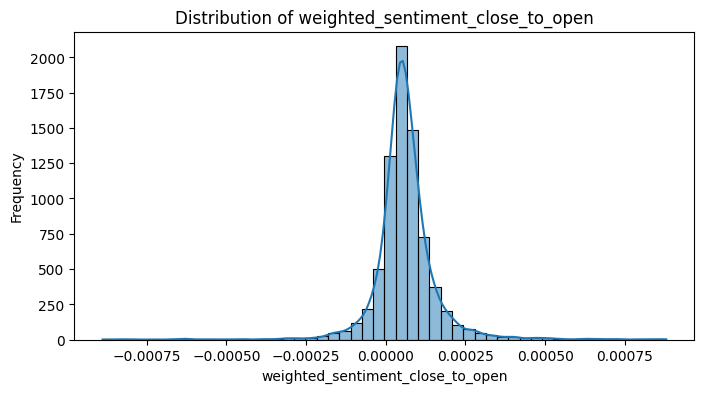

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['weighted_sentiment_close_to_open'], bins=50, kde=True)
plt.title('Distribution of weighted_sentiment_close_to_open')
plt.xlabel('weighted_sentiment_close_to_open')
plt.ylabel('Frequency')
plt.show()


In [39]:
df['ticker_symbol'].value_counts()

ticker_symbol
GOOGL    1258
AMZN     1257
GOOG     1256
TSLA     1255
AAPL     1252
MSFT     1252
Name: count, dtype: int64

In [40]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode trend labels
df['open_to_open_trend_encoded'] = LabelEncoder().fit_transform(df['open_to_open_return'])

df = df.drop(columns=['open_to_open_return'])

## Feature Engineering and Technical Indicators

This step enhances the dataset with technical indicators and sentiment-based features for each stock:

- **Datetime Conversion & Sorting**: Ensures dates are in correct format and data is sorted per stock (`ticker_symbol`).
- **Technical Indicators**: Calculates moving averages (`MA7`, `MA20`), exponential moving average (`EMA`), Bollinger Bands (`upper_band`, `lower_band`), MACD, standard deviation (`20SD`), and 5-day log momentum.
- **Sentiment Features**: Adds lag-1 and 5-day rolling averages for both mapped and weighted sentiment variables.
- **Price and Volume Lags**: Adds lag-1 and rolling means for `close_value` and `volume`.
- **Spread Features**: Computes daily `high-low` and `open-close` spreads.
- **Day of Week**: Extracts day of the week from the date as a categorical feature (`0=Monday`, ..., `6=Sunday`).
- **Cleanup**: Drops missing values caused by shifting and rolling operations.

>  This prepares the dataset for modeling stock return trends using historical, technical, and sentiment-based signals.


In [41]:

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker_symbol', 'date'])

# Group by ticker to compute indicators per stock
def add_technical_indicators(group):
    group = group.copy()
    
    # Moving Averages
    group['MA7'] = group['close_value'].rolling(window=7).mean()
    group['MA20'] = group['close_value'].rolling(window=20).mean()
    
    # Exponential Moving Average
    group['EMA'] = group['close_value'].ewm(span=20, adjust=False).mean()
    
    # Standard Deviation (20-day)
    group['20SD'] = group['close_value'].rolling(window=20).std()
    
    # Bollinger Bands
    group['upper_band'] = group['MA20'] + 2 * group['20SD']
    group['lower_band'] = group['MA20'] - 2 * group['20SD']
    
    # MACD (12-EMA - 26-EMA)
    ema_12 = group['close_value'].ewm(span=12, adjust=False).mean()
    ema_26 = group['close_value'].ewm(span=26, adjust=False).mean()
    group['MACD'] = ema_12 - ema_26
    
    # Log Momentum (5-day)
    group['logmomentum'] = np.log(group['close_value'] / group['close_value'].shift(5))
    
    return group

# Apply to each ticker
df = df.groupby('ticker_symbol').apply(add_technical_indicators).reset_index(drop=True)

# Feature engineering
feature_df = df.copy()
feature_df = feature_df.sort_values(by=["ticker_symbol", "date"])
feature_df['close_lag1'] = feature_df.groupby('ticker_symbol')['close_value'].shift(1)
feature_df['volume_lag1'] = feature_df.groupby('ticker_symbol')['volume'].shift(1)
# List of sentiment columns
sentiment_cols = [
    'sentiment_mapped_close_to_open',
    'sentiment_mapped_open_to_close',
    'weighted_sentiment_close_to_open',
    'weighted_sentiment_open_to_close'
]

# Apply both lag1 and rolling mean
for col in sentiment_cols:
    feature_df[f'{col}_lag1'] = feature_df.groupby('ticker_symbol')[col].shift(1)
    feature_df[f'{col}_rolling_mean_5'] = feature_df.groupby('ticker_symbol')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

feature_df['close_rolling_mean_5'] = feature_df.groupby('ticker_symbol')['close_value'].transform(lambda x: x.rolling(window=5).mean())
feature_df['volume_rolling_mean_5'] = feature_df.groupby('ticker_symbol')['volume'].transform(lambda x: x.rolling(window=5).mean())
feature_df['high_low_spread'] = feature_df['high_value'] - feature_df['low_value']
feature_df['open_close_spread'] = feature_df['open_value'] - feature_df['close_value']
# Ensure 'date' column is datetime
feature_df['date'] = pd.to_datetime(feature_df['date'], errors='coerce')

# Now extract day of week
feature_df['day_of_week'] = feature_df['date'].dt.dayofweek

feature_df = feature_df.dropna().reset_index(drop=True)

df = feature_df.copy()
df.head()

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2253514677.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker_symbol').apply(add_technical_indicators).reset_index(drop=True)


,ticker_symbol,date,close_value,volume,open_value,high_value,low_value,sentiment_mapped_close_to_open,sentiment_mapped_open_to_close,weighted_sentiment_close_to_open,weighted_sentiment_open_to_close,open_to_open_trend_encoded,MA7,MA20,EMA,20SD,upper_band,lower_band,MACD,logmomentum,close_lag1,volume_lag1,sentiment_mapped_close_to_open_lag1,sentiment_mapped_close_to_open_rolling_mean_5,sentiment_mapped_open_to_close_lag1,sentiment_mapped_open_to_close_rolling_mean_5,weighted_sentiment_close_to_open_lag1,weighted_sentiment_close_to_open_rolling_mean_5,weighted_sentiment_open_to_close_lag1,weighted_sentiment_open_to_close_rolling_mean_5,close_rolling_mean_5,volume_rolling_mean_5,high_low_spread,open_close_spread,day_of_week
0,AAPL,2015-01-30,117.16,83646800,118.40,120.00,116.850,-0.114263,-0.218487,-0.000018,-2.055452e-04,0,114.141429,110.6415,111.755517,3.593043,117.827587,103.455413,1.710889,0.036330,118.90,84132130.0,-0.166175,-0.131491,-0.119281,-0.164090,-0.000094,-0.000064,-4.837739e-05,-0.000095,114.722,92349458.0,3.150,1.24,4
1,AAPL,2015-02-02,118.63,62542440,118.05,119.17,116.080,-0.109896,0.047739,0.000003,3.669086e-05,1,115.031429,111.1065,112.410230,3.993817,119.094133,103.118867,2.035887,0.047737,117.16,83646800.0,-0.114263,-0.145724,-0.218487,-0.148963,-0.000018,-0.000056,-2.055452e-04,-0.000081,115.828,93766462.0,3.090,-0.58,0
2,AAPL,2015-02-04,119.56,69975180,118.50,120.51,118.309,0.081831,-0.034409,-0.000037,-1.520480e-04,1,115.971429,111.7720,113.091161,4.243131,120.258263,103.285737,2.341502,0.091187,118.63,62542440.0,-0.109896,-0.104288,0.047739,-0.121595,0.000003,-0.000047,3.669086e-05,-0.000103,117.912,89296170.0,2.201,-1.06,2
3,AAPL,2015-02-06,118.93,43633660,120.02,120.25,118.450,0.036671,0.034582,0.000075,4.788897e-07,0,116.804286,112.4055,113.647241,4.321960,121.049421,103.761579,2.504003,0.030911,119.56,69975180.0,0.081831,-0.054366,-0.034409,-0.057971,-0.000037,-0.000014,-1.520480e-04,-0.000074,118.636,68786042.0,1.800,1.09,4
4,AAPL,2015-02-09,119.72,37900780,118.55,119.84,118.430,0.020537,-0.038732,0.000026,-7.867167e-05,1,118.315714,113.0040,114.225599,4.469615,121.943230,104.064770,2.665804,0.006873,118.93,43633660.0,0.036671,-0.017024,0.034582,-0.041862,0.000075,0.000010,4.788897e-07,-0.000080,118.800,59539772.0,1.410,-1.17,0


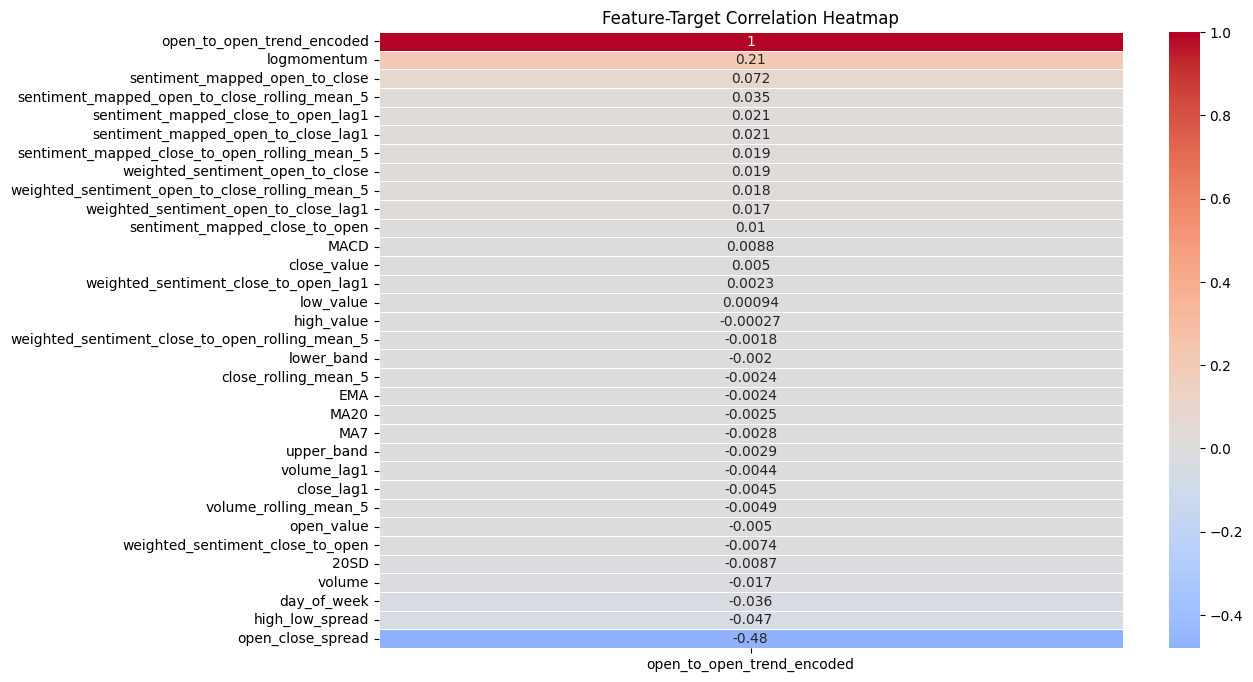

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df'
# Ensure your target variable column name (binary encoded) is correct
target_col = 'open_to_open_trend_encoded'  # 

# Select only numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[[target_col]].sort_values(by=target_col, ascending=False), 
            annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature-Target Correlation Heatmap')
plt.show()


##  Feature Scaling with Standardization

To ensure all features contribute equally to the model:

- **Exclude Non-Numeric and Target Columns**: Removes `ticker_symbol`, `date`, and the target variable `open_to_open_trend_encoded` from scaling.
- **StandardScaler**: Applies `StandardScaler` to the remaining features to center them (mean = 0) and scale to unit variance (std = 1).
  
This step improves convergence and performance of many machine learning models, especially those sensitive to feature scales (e.g., SVM, Logistic Regression, Neural Networks).


In [43]:
from sklearn.preprocessing import StandardScaler

# Drop non-numeric or target columns
features_to_scale = df.drop(columns=[
    'ticker_symbol', 'date', 
    'open_to_open_trend_encoded'
]).columns

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


##  Feature Set Construction

This step prepares inputs for model training:

- **Lagged Sentiment for Tomorrow**: Adds next-day (`shift(-1)`) sentiment signals for modeling open-to-open trends.
- **Base Features**: Includes technical indicators, lags, spreads, and temporal info.
- **Sentiment Feature Sets**:
  - *open_sentiment_basic*: Uses raw sentiment scores.
  - *open_sentiment_weighted*: Incorporates PageRank-weighted sentiment.
  - *open_no_sentiment*: Baseline without sentiment.

Combines each sentiment set with base features to define multiple input configurations.


In [44]:

# Generate lag and lead sentiment features based on close/open structure
df['sentiment_mapped_close_to_open_tomorrow'] = df.groupby('ticker_symbol')['sentiment_mapped_close_to_open'].shift(-1)

df['weighted_sentiment_close_to_open_tomorrow'] = df.groupby('ticker_symbol')['weighted_sentiment_close_to_open'].shift(-1)

df = df.dropna()
# Base features
base_features = [
    'close_value', 'volume', 'open_value',
    'high_value', 'low_value', 
    'MA7', 'MA20', 'EMA', '20SD', 'upper_band',
    'lower_band', 'MACD', 'logmomentum', 
    'close_lag1', 'volume_lag1', 'high_low_spread', 'open_close_spread',
    'close_rolling_mean_5', 'volume_rolling_mean_5',
    'day_of_week'
]

# Sentiment feature sets
feature_sets_raw = {
    'open_sentiment_basic': [
        'sentiment_mapped_open_to_close',
        'sentiment_mapped_close_to_open_tomorrow',
        'sentiment_mapped_open_to_close_lag1',
        'sentiment_mapped_open_to_close_rolling_mean_5',
        'sentiment_mapped_close_to_open_lag1',
        'sentiment_mapped_close_to_open_rolling_mean_5'
    ],
    'open_sentiment_weighted': [
        'weighted_sentiment_open_to_close',
        'weighted_sentiment_close_to_open_tomorrow',
        'weighted_sentiment_open_to_close_lag1',
        'weighted_sentiment_open_to_close_rolling_mean_5',
        'weighted_sentiment_close_to_open_lag1',
        'weighted_sentiment_close_to_open_rolling_mean_5'
    ],
    'open_no_sentiment': []
}

# Combine base + sentiment features
feature_sets = {
    name: base_features + features
    for name, features in feature_sets_raw.items()
}

### Open Price and Sentiment Over Time

Each subplot visualizes the relationship between market opening prices and sentiment for a specific stock ticker over time.

- **Blue Line (Left Y-axis): Open Price**  
  Shows the daily market opening price of the stock. It reflects how the market values the stock at the start of each trading day.

- **Red Line (Right Y-axis): Weighted Sentiment (Close to Open)**  
  Represents the sentiment score derived from tweets posted before market open (from the previous close to the next open), weighted by tweet importance (e.g., PageRank). This sentiment reflects public opinion or expectations about the stock before trading begins.

- **Gray Dashed Line at 0 (Right Y-axis)**  
  Serves as a reference line for sentiment polarity:  
  - *Above 0*: Positive sentiment  
  - *Below 0*: Negative sentiment

By comparing both lines, we can visually assess how sentiment fluctuates and whether it potentially anticipates movements in the next day's opening price.


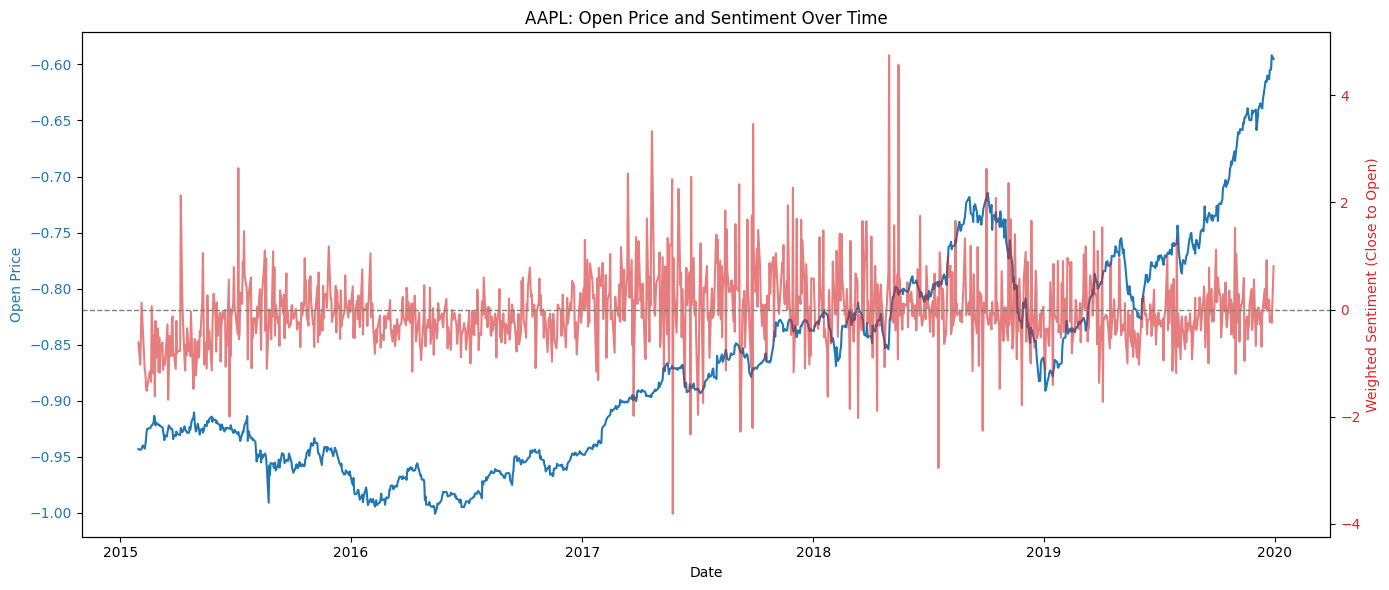

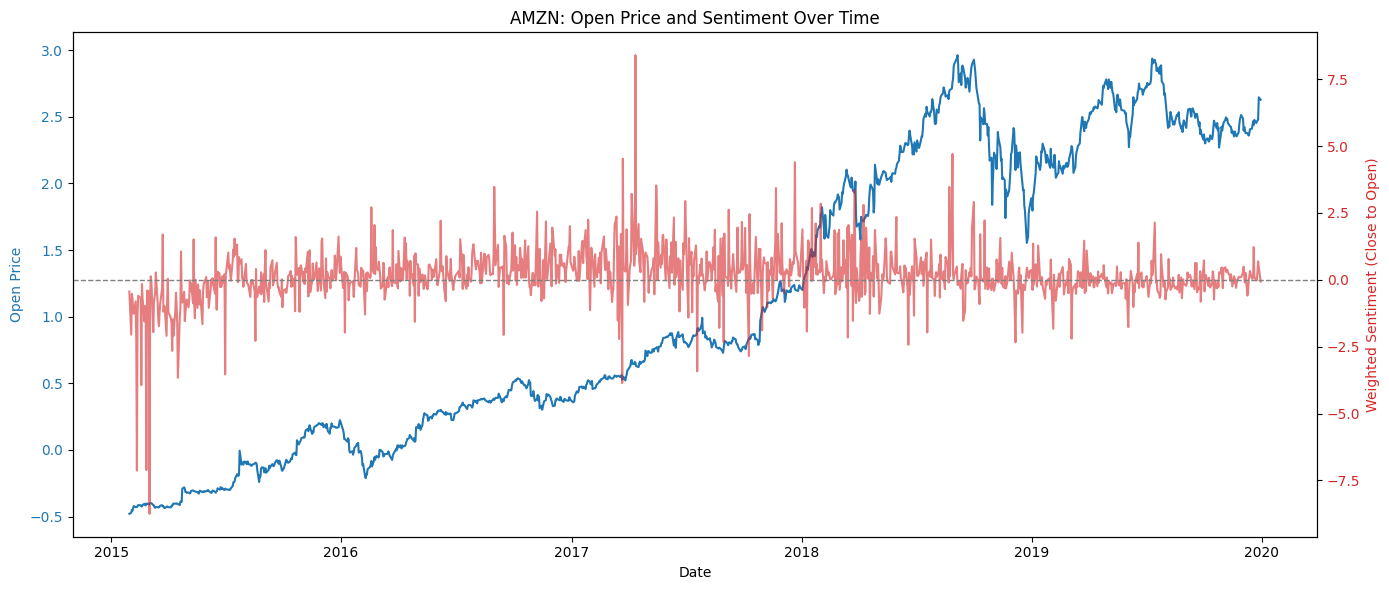

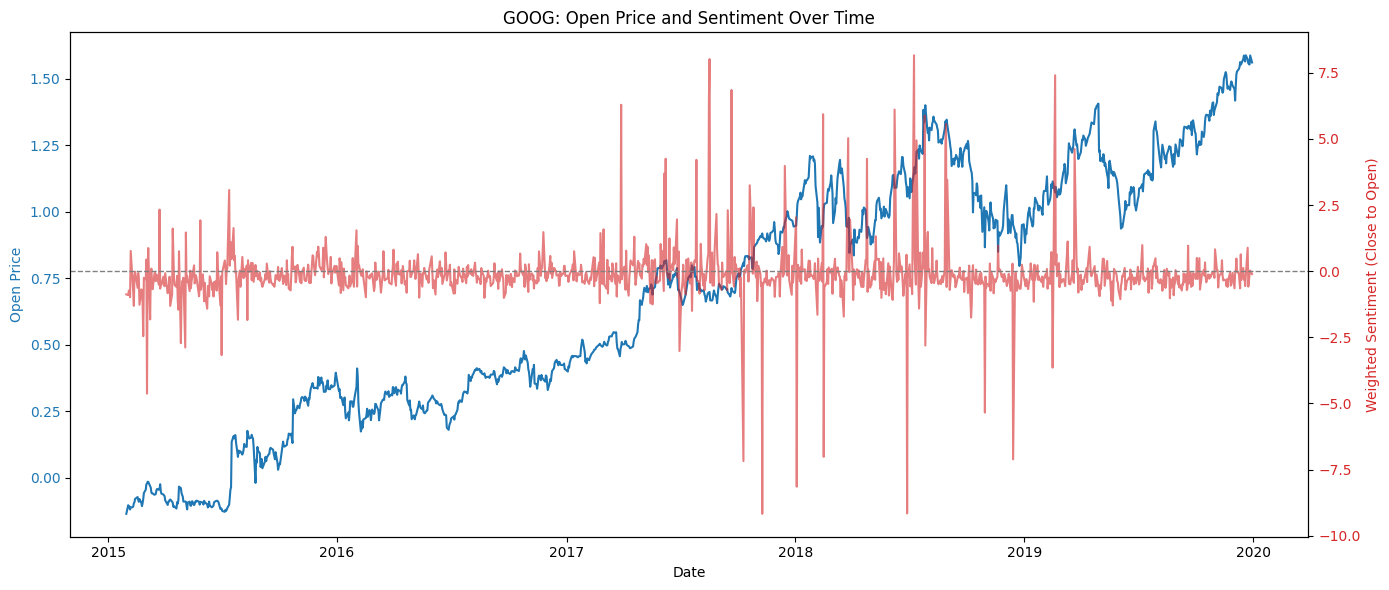

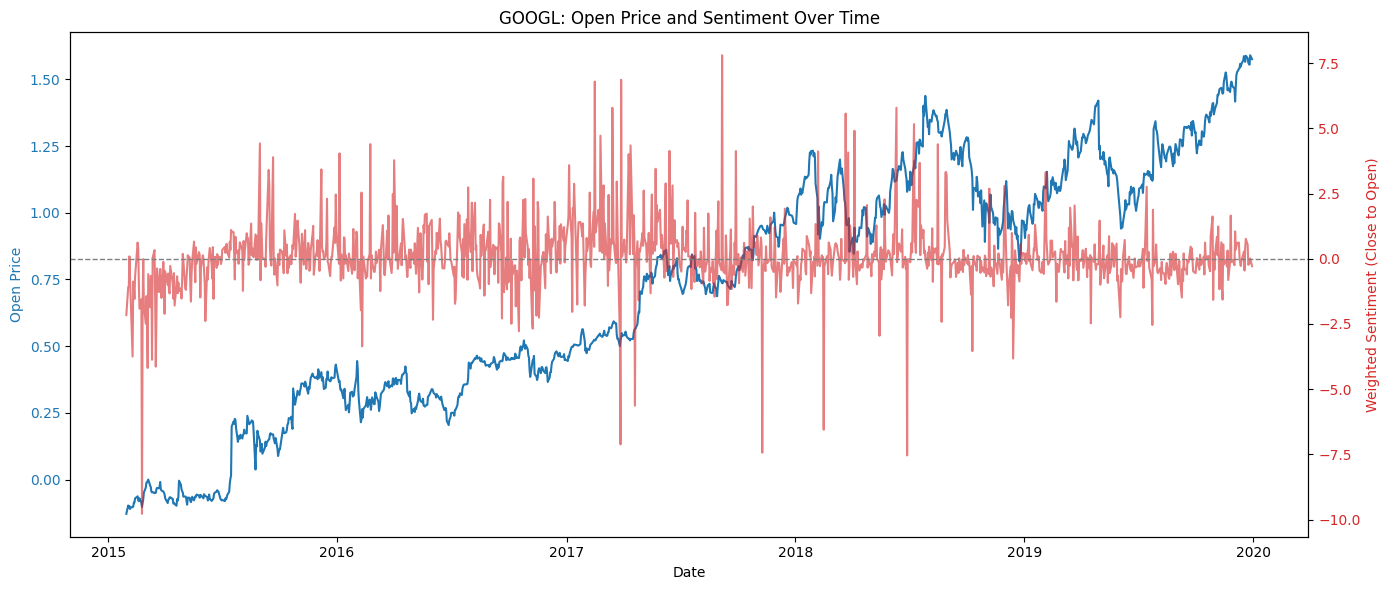

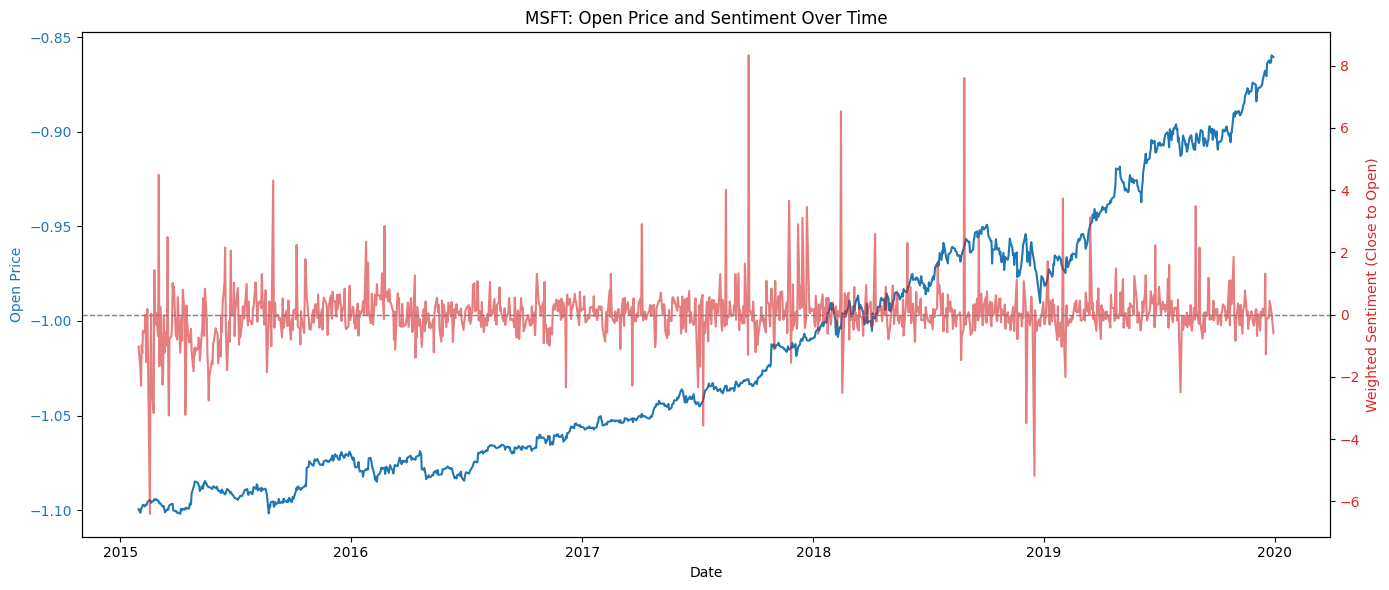

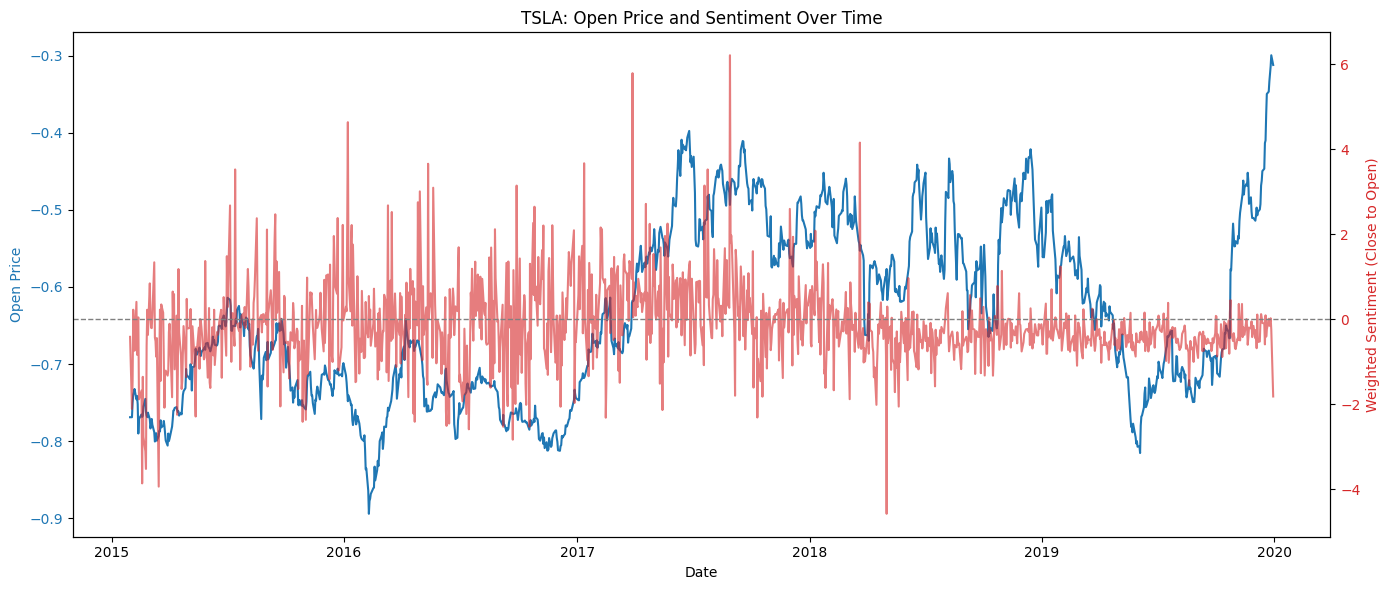

In [45]:
import matplotlib.pyplot as plt

# Loop over all tickers
for ticker in df['ticker_symbol'].unique():
    df_ticker = df[df['ticker_symbol'] == ticker].copy()
    df_ticker['date'] = pd.to_datetime(df_ticker['date'])

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Plot open price
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Open Price', color='tab:blue')
    ax1.plot(df_ticker['date'], df_ticker['open_value'], color='tab:blue', label='Open Price')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Sentiment plot
    ax2 = ax1.twinx()
    ax2.set_ylabel('Weighted Sentiment (Close to Open)', color='tab:red')
    ax2.plot(df_ticker['date'], df_ticker['weighted_sentiment_close_to_open_tomorrow'], color='tab:red', alpha=0.6)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(f'{ticker}: Open Price and Sentiment Over Time')
    fig.tight_layout()
    plt.show()


### Model Evaluation Pipeline

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np
from sklearn.model_selection import ParameterGrid
import joblib

def preprocess_data(df, feature_set, target_label):
    X = df[feature_set]
    y = df[target_label]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y, scaler

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    return report

def run_experiments(df, feature_sets, models, target_label):
    all_results = []
    for ticker in df['ticker_symbol'].unique():
        df_ticker = df[df['ticker_symbol'] == ticker].copy().sort_values('date')
        train = df_ticker[(df_ticker['date'] >= '2015-01-01') & (df_ticker['date'] <= '2018-12-31')]
        test  = df_ticker[(df_ticker['date'] >= '2019-01-01') & (df_ticker['date'] <= '2019-12-31')]

        if len(train) < 100 or len(test) < 50:
            continue

        for feat_set_name, feat_set in feature_sets.items():
            X_train, y_train, _ = preprocess_data(train, feat_set, target_label)
            X_test, y_test, _ = preprocess_data(test, feat_set, target_label)

            for model_name, model in models.items():
                try:
                    report = evaluate_model(model, X_train, y_train, X_test, y_test)
                    all_results.append({
                        'ticker': ticker,
                        'feature_set': feat_set_name,
                        'model': model_name,
                        'accuracy': report['accuracy'],
                        'macro_f1': report['macro avg']['f1-score'],
                        'weighted_f1': report['weighted avg']['f1-score']
                    })
                except Exception as e:
                    print(f"Error on {ticker}-{model_name}-{feat_set_name}: {e}")
    return pd.DataFrame(all_results)




###  Model Setup for Trend Classification

This code initializes a set of machine learning classifiers to predict stock trends (`open_to_open_trend_encoded`). It includes:

* **Linear model**: `LogisticRegression`
* **Kernel-based model**: `SVM`
* **Tree-based models**: `RandomForest`, `GradientBoosting`, `BaggingClassifier`, `XGBoost`, `LightGBM`, `CatBoost`
* **Neural network**: `MLPClassifier`

Each model is configured with basic or optimized parameters. The target variable for prediction is `open_to_open_trend_encoded`.


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from lightgbm import LGBMClassifier

import pandas as pd
# Models
models = {
    'LogisticRegression': LogisticRegression(max_iter=200),
    'SVM': SVC(),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    'Bagging (Decision Tree)': BaggingClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMClassifier(verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0)
}

# Target variable
target_label = 'open_to_open_trend_encoded'

In [48]:
# results_df = run_experiments(df, feature_sets, models, target_label)


In [ ]:
# import joblib

# # Save
# joblib.dump(results_df, 'model_results.pkl')



In [102]:
# #Load later
import joblib
results_df = joblib.load('model_results.pkl')

In [103]:
results_df.columns.tolist()



['ticker', 'feature_set', 'model', 'accuracy', 'macro_f1', 'weighted_f1']



###  Paired t-test: Weighted Sentiment vs No Sentiment

This script performs a **paired t-test** for each model to compare the **weighted F1-scores** between:

* `open_sentiment_weighted`
* `open_no_sentiment`

It tests if the difference in performance across tickers is **statistically significant**, printing the t-statistic and p-value for each model (only if the same tickers exist in both sets).


In [104]:
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create result summary
tickers = results_df['ticker'].unique()
models = results_df['model'].unique()

summary = []

for ticker in tickers:
    df_sent = results_df.query("feature_set == 'open_sentiment_weighted' and ticker == @ticker").sort_values('model')
    df_nosent = results_df.query("feature_set == 'open_no_sentiment' and ticker == @ticker").sort_values('model')
    
    if len(df_sent) == len(df_nosent) and len(df_sent) > 1:
        sent_scores = df_sent['weighted_f1'].values
        nosent_scores = df_nosent['weighted_f1'].values

        # Paired t-test
        t_stat, p_val_t = ttest_rel(sent_scores, nosent_scores)

        # Wilcoxon signed-rank test
        try:
            w_stat, p_val_w = wilcoxon(sent_scores, nosent_scores)
        except ValueError:
            w_stat, p_val_w = np.nan, np.nan  # If all differences are zero

        # Effect size (Cohen's d)
        diff = sent_scores - nosent_scores
        cohen_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan

        summary.append({
            'ticker': ticker,
            'mean_sentiment_f1': sent_scores.mean(),
            'mean_no_sentiment_f1': nosent_scores.mean(),
            'mean_diff': diff.mean(),
            't_stat': t_stat,
            'p_val_t': p_val_t,
            'w_stat': w_stat,
            'p_val_w': p_val_w,
            'cohen_d': cohen_d
        })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='mean_diff', ascending=False)


In [105]:
summary_df

,ticker,mean_sentiment_f1,mean_no_sentiment_f1,mean_diff,t_stat,p_val_t,w_stat,p_val_w,cohen_d
5,TSLA,0.833372,0.824188,0.009184,1.296986,0.230789,12.0,0.250000,0.432329
4,MSFT,0.817075,0.809387,0.007688,1.627170,0.142352,9.0,0.128906,0.542390
0,AAPL,0.763992,0.757717,0.006276,4.299935,0.002616,0.0,0.003906,1.433312
3,GOOGL,0.828467,0.827514,0.000953,0.167590,0.871065,20.0,0.820312,0.055863
1,AMZN,0.814725,0.815660,-0.000936,-0.268448,0.795147,20.0,0.820312,-0.089483
2,GOOG,0.798934,0.811317,-0.012383,-1.650920,0.137361,10.0,0.164062,-0.550307


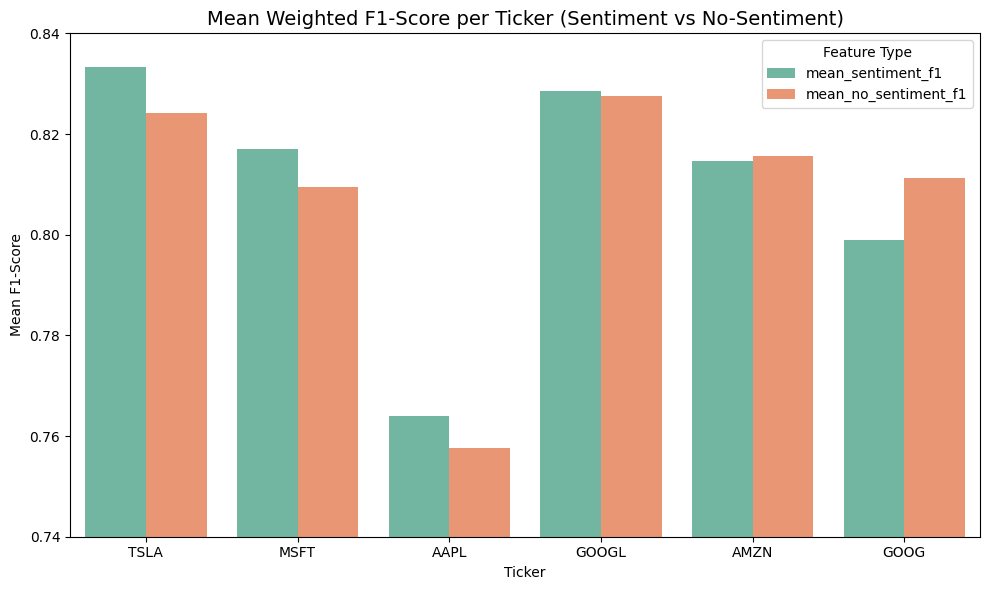

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data (restructured from your HTML table)
data = {
    'ticker': ['TSLA', 'MSFT', 'AAPL', 'GOOGL', 'AMZN', 'GOOG'],
    'mean_sentiment_f1': [0.833372, 0.817075, 0.763992, 0.828467, 0.814725, 0.798934],
    'mean_no_sentiment_f1': [0.824188, 0.809387, 0.757717, 0.827514, 0.815660, 0.811317],
    'mean_diff': [0.009184, 0.007688, 0.006276, 0.000953, -0.000936, -0.012383],
    't_stat': [1.296986, 1.627170, 4.299935, 0.167590, -0.268448, -1.650920],
    'p_val_t': [0.230789, 0.142352, 0.002616, 0.871065, 0.795147, 0.137361],
    'cohen_d': [0.432329, 0.542390, 1.433312, 0.055863, -0.089483, -0.550307]
}
df = pd.DataFrame(data)

# Melt data for plotting
df_melted = df.melt(id_vars='ticker', value_vars=['mean_sentiment_f1', 'mean_no_sentiment_f1'],
                    var_name='Feature Type', value_name='Mean F1-Score')

# Barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='ticker', y='Mean F1-Score', hue='Feature Type', data=df_melted, palette='Set2')
plt.title("Mean Weighted F1-Score per Ticker (Sentiment vs No-Sentiment)", fontsize=14)
plt.ylabel("Mean F1-Score")
plt.xlabel("Ticker")
plt.ylim(0.74, 0.84)
plt.tight_layout()
plt.show()


/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/1714770739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ticker', y='mean_diff', data=summary_df, palette='coolwarm')


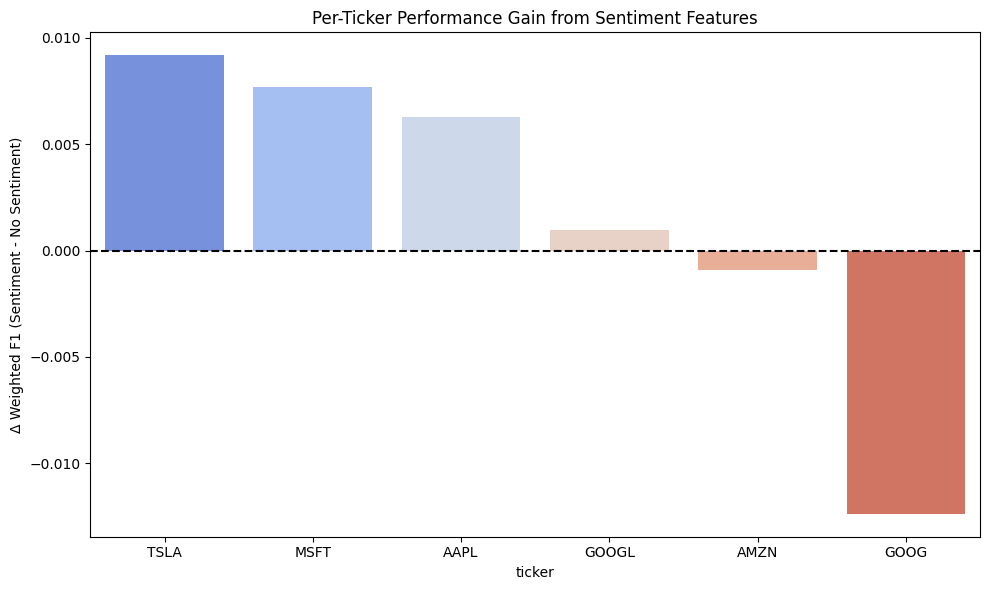

In [79]:
# Bar plot of delta F1 per ticker
plt.figure(figsize=(10, 6))
sns.barplot(x='ticker', y='mean_diff', data=summary_df, palette='coolwarm')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Δ Weighted F1 (Sentiment - No Sentiment)')
plt.title('Per-Ticker Performance Gain from Sentiment Features')
plt.tight_layout()
plt.show()


In [80]:
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

summary_df['significance'] = summary_df['p_val_t'].apply(significance_stars)

print(summary_df[['ticker', 'mean_diff', 'p_val_t', 'p_val_w', 'cohen_d', 'significance']])


  ticker  mean_diff   p_val_t   p_val_w   cohen_d significance
5   TSLA   0.009184  0.230789  0.250000  0.432329             
4   MSFT   0.007688  0.142352  0.128906  0.542390             
0   AAPL   0.006276  0.002616  0.003906  1.433312           **
3  GOOGL   0.000953  0.871065  0.820312  0.055863             
1   AMZN  -0.000936  0.795147  0.820312 -0.089483             
2   GOOG  -0.012383  0.137361  0.164062 -0.550307             


In [81]:
summary_df.to_csv("sentiment_vs_no_sentiment_summary.csv", index=False)


In [77]:
tickers = results_df['ticker'].unique()
models = results_df['model'].unique()

print("Paired t-test per Ticker (Sentiment vs No-Sentiment — weighted_f1)\n")
print(f"{'Ticker':<10} {'T-stat':>10} {'P-value':>10}")
print("-" * 40)

for ticker in tickers:
    # Sort by model for alignment
    weighted = results_df.query(f"feature_set == 'open_sentiment_weighted' and ticker == '{ticker}'") \
                         .sort_values(by='model')['weighted_f1']
    no_sent = results_df.query(f"feature_set == 'open_no_sentiment' and ticker == '{ticker}'") \
                        .sort_values(by='model')['weighted_f1']

    if len(weighted) == len(no_sent) and len(weighted) > 1:
        t_stat, p_val = ttest_rel(weighted, no_sent)
        print(f"{ticker:<10} {t_stat:10.4f} {p_val:10.4f}")
    else:
        print(f"{ticker:<10} {'N/A':>10} {'N/A':>10} (Insufficient data)")


Paired t-test per Ticker (Sentiment vs No-Sentiment — weighted_f1)

Ticker         T-stat    P-value
----------------------------------------
AAPL           4.2999     0.0026
AMZN          -0.2684     0.7951
GOOG          -1.6509     0.1374
GOOGL          0.1676     0.8711
MSFT           1.6272     0.1424
TSLA           1.2970     0.2308


In [73]:
from scipy.stats import ttest_rel
import pandas as pd

# Grouped paired t-test across models
models = results_df['model'].unique()

print("Paired t-test results (Weighted Sentiment vs No Sentiment)\n")
print(f"{'Model':<25} {'T-stat':>10} {'P-value':>10}")
print("-" * 50)

for model in models:
    weighted = results_df.query(f"feature_set == 'open_sentiment_weighted' and model == '{model}'") \
                         .sort_values(by=['ticker'])['weighted_f1']
    no_sent = results_df.query(f"feature_set == 'open_no_sentiment' and model == '{model}'") \
                        .sort_values(by=['ticker'])['weighted_f1']

    # Only compare if lengths match (i.e., same tickers are present)
    if len(weighted) == len(no_sent) and len(weighted) > 1:
        t_stat, p_val = ttest_rel(weighted, no_sent)
        print(f"{model:<25} {t_stat:10.4f} {p_val:10.4f}")
    else:
        print(f"{model:<25} {'N/A':>10} {'N/A':>10}  (Insufficient matching data)")


Paired t-test results (Weighted Sentiment vs No Sentiment)

Model                         T-stat    P-value
--------------------------------------------------
LogisticRegression           -0.3893     0.7131
SVM                          -1.3961     0.2215
RandomForest                  0.0877     0.9335
XGBoost                       2.4800     0.0558
MLP                          -0.5594     0.6000
Bagging (Decision Tree)       0.6944     0.5184
GradientBoosting              1.7751     0.1361
LightGBM                     -0.3784     0.7207
CatBoost                      0.2997     0.7765



### Paired T-Test for LogisticRegression

This code compares the **`weighted_f1` scores** of the `LogisticRegression` model between two feature sets:

* `open_sentiment_weighted`
* `open_no_sentiment`

It uses a **paired t-test** (`ttest_rel`) to test if the difference in performance is **statistically significant**.

Result:
`t` = test statistic
`p` = p-value (significance)


In [52]:
from scipy.stats import ttest_rel

# Example: Compare weighted vs no sentiment models for LogisticRegression
weighted = results_df.query("feature_set == 'open_sentiment_weighted' and model == 'LogisticRegression'")['weighted_f1']
no_sent = results_df.query("feature_set == 'open_no_sentiment' and model == 'LogisticRegression'")['weighted_f1']

t_stat, p_val = ttest_rel(weighted, no_sent)
print(f"T-test: t={t_stat:.4f}, p={p_val:.4f}")


T-test: t=-0.3893, p=0.7131


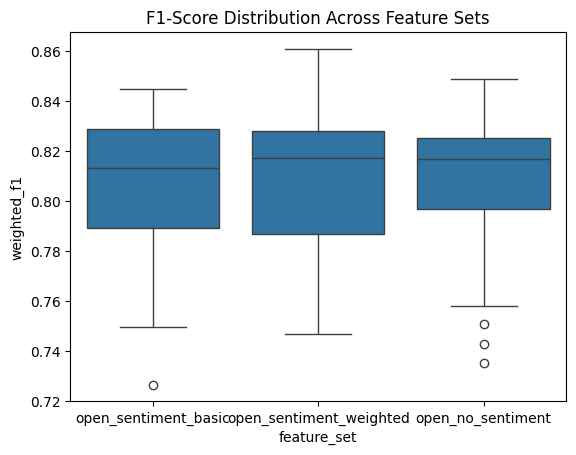

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='feature_set', y='weighted_f1', data=results_df)
plt.title('F1-Score Distribution Across Feature Sets')
plt.show()


In [82]:
import pandas as pd
import os

# Step 1–5 remain the same
with_sentiment = results_df[~results_df['feature_set'].str.endswith('no_sentiment')]

best_results = (
    with_sentiment
    .groupby(['ticker', 'model'], as_index=False)
    .apply(lambda g: g.loc[g['weighted_f1'].idxmax()], include_groups=False)
    .reset_index(drop=True)
)

no_sentiment = results_df[results_df['feature_set'].str.endswith('no_sentiment')]

comparison_df = pd.merge(
    best_results,
    no_sentiment,
    on=['ticker', 'model'],
    suffixes=('_best', '_no_sentiment')
)

comparison_df['accuracy_improvement'] = comparison_df['accuracy_best'] - comparison_df['accuracy_no_sentiment']
comparison_df['f1_improvement'] = comparison_df['weighted_f1_best'] - comparison_df['weighted_f1_no_sentiment']

# Clean and select output columns
cols = [
    'ticker', 'model',
    'feature_set_best', 'accuracy_best', 'weighted_f1_best',
    'feature_set_no_sentiment', 'accuracy_no_sentiment', 'weighted_f1_no_sentiment',
    'accuracy_improvement', 'f1_improvement'
]

comparison_df = comparison_df[cols]

# Step 6: Create dictionary of DataFrames by ticker
ticker_dfs = {ticker: df for ticker, df in comparison_df.groupby('ticker')}

# Step 7: Optionally save each to CSV (uncomment if needed)
output_dir = "ticker_comparisons"
os.makedirs(output_dir, exist_ok=True)

for ticker, df in ticker_dfs.items():
    file_path = os.path.join(output_dir, f"{ticker}_comparison.csv")
    df.to_csv(file_path, index=False)
    print(f"✅ Saved: {file_path}")


✅ Saved: ticker_comparisons/AAPL_comparison.csv
✅ Saved: ticker_comparisons/AMZN_comparison.csv
✅ Saved: ticker_comparisons/GOOG_comparison.csv
✅ Saved: ticker_comparisons/GOOGL_comparison.csv
✅ Saved: ticker_comparisons/MSFT_comparison.csv
✅ Saved: ticker_comparisons/TSLA_comparison.csv


In [84]:
AAPL_comparison = pd.read_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Master_Thesis copy/ticker_comparisons/AAPL_comparison.csv')

In [85]:
AAPL_comparison

,ticker,model,feature_set_best,accuracy_best,weighted_f1_best,feature_set_no_sentiment,accuracy_no_sentiment,weighted_f1_no_sentiment,accuracy_improvement,f1_improvement
0,AAPL,Bagging (Decision Tree),open_sentiment_weighted,0.752988,0.754812,open_no_sentiment,0.741036,0.742784,0.011952,0.012028
1,AAPL,CatBoost,open_sentiment_basic,0.764940,0.766657,open_no_sentiment,0.760956,0.762681,0.003984,0.003977
2,AAPL,GradientBoosting,open_sentiment_basic,0.752988,0.754786,open_no_sentiment,0.733068,0.735029,0.019920,0.019757
3,AAPL,LightGBM,open_sentiment_basic,0.768924,0.770591,open_no_sentiment,0.760956,0.762614,0.007968,0.007977
4,AAPL,LogisticRegression,open_sentiment_basic,0.768924,0.770591,open_no_sentiment,0.764940,0.766527,0.003984,0.004064
5,AAPL,MLP,open_sentiment_basic,0.772908,0.774587,open_no_sentiment,0.749004,0.750837,0.023904,0.023749
6,AAPL,RandomForest,open_sentiment_weighted,0.768924,0.770631,open_no_sentiment,0.756972,0.758696,0.011952,0.011935
7,AAPL,SVM,open_sentiment_basic,0.788845,0.790044,open_no_sentiment,0.768924,0.769972,0.019920,0.020072
8,AAPL,XGBoost,open_sentiment_weighted,0.772908,0.774519,open_no_sentiment,0.768924,0.770310,0.003984,0.004209


In [87]:
import pandas as pd

# Step 1: Keep only models that use sentiment
with_sentiment = results_df[~results_df['feature_set'].str.endswith('no_sentiment')]

# Step 2: Best (highest weighted_f1) per (ticker, model)
best_results = (
    with_sentiment
    .groupby(['ticker', 'model'], as_index=False)
    .apply(lambda g: g.loc[g['weighted_f1'].idxmax()], include_groups=False)
    .reset_index(drop=True)
)

# Step 3: Extract corresponding no_sentiment results
no_sentiment = results_df[results_df['feature_set'].str.endswith('no_sentiment')]

# Step 4: Merge to compare best sentiment-based vs no-sentiment
comparison_df = pd.merge(
    best_results,
    no_sentiment,
    on=['ticker', 'model'],
    suffixes=('_best', '_no_sentiment')
)

# Step 5: Calculate improvement
comparison_df['accuracy_improvement'] = comparison_df['accuracy_best'] - comparison_df['accuracy_no_sentiment']
comparison_df['f1_improvement'] = comparison_df['weighted_f1_best'] - comparison_df['weighted_f1_no_sentiment']

# Display options
pd.set_option('display.max_rows', 160)
pd.set_option('display.max_columns', None)

# Columns for output
cols = [
    'ticker', 'model',
    'feature_set_best', 'accuracy_best', 'weighted_f1_best',
    'feature_set_no_sentiment', 'accuracy_no_sentiment', 'weighted_f1_no_sentiment',
    'accuracy_improvement', 'f1_improvement'
]

# Show results grouped by ticker, sorted by F1 gain
for ticker in comparison_df['ticker'].unique():
    print(f"\n--- Results for Ticker: {ticker} ---")
    df_sorted = comparison_df[comparison_df['ticker'] == ticker].sort_values(by='f1_improvement', ascending=False)
    print(df_sorted[cols].to_string(index=False))



--- Results for Ticker: AAPL ---
ticker                   model        feature_set_best  accuracy_best  weighted_f1_best feature_set_no_sentiment  accuracy_no_sentiment  weighted_f1_no_sentiment  accuracy_improvement  f1_improvement
  AAPL                     MLP    open_sentiment_basic       0.772908          0.774587        open_no_sentiment               0.749004                  0.750837              0.023904        0.023749
  AAPL                     SVM    open_sentiment_basic       0.788845          0.790044        open_no_sentiment               0.768924                  0.769972              0.019920        0.020072
  AAPL        GradientBoosting    open_sentiment_basic       0.752988          0.754786        open_no_sentiment               0.733068                  0.735029              0.019920        0.019757
  AAPL Bagging (Decision Tree) open_sentiment_weighted       0.752988          0.754812        open_no_sentiment               0.741036                  0.742784     

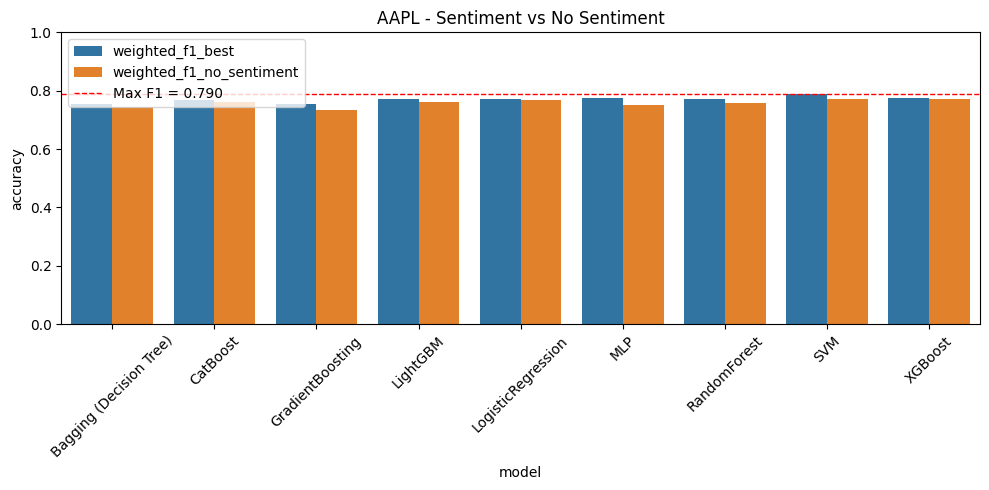

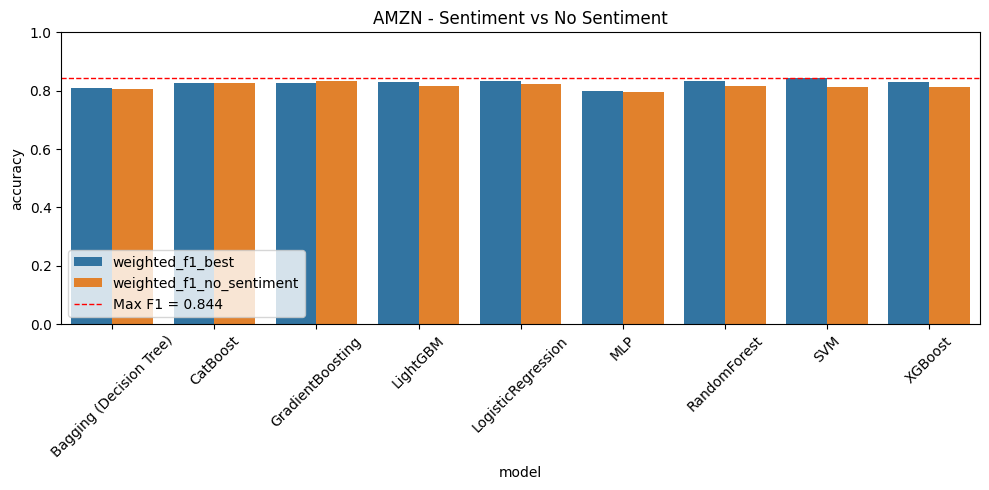

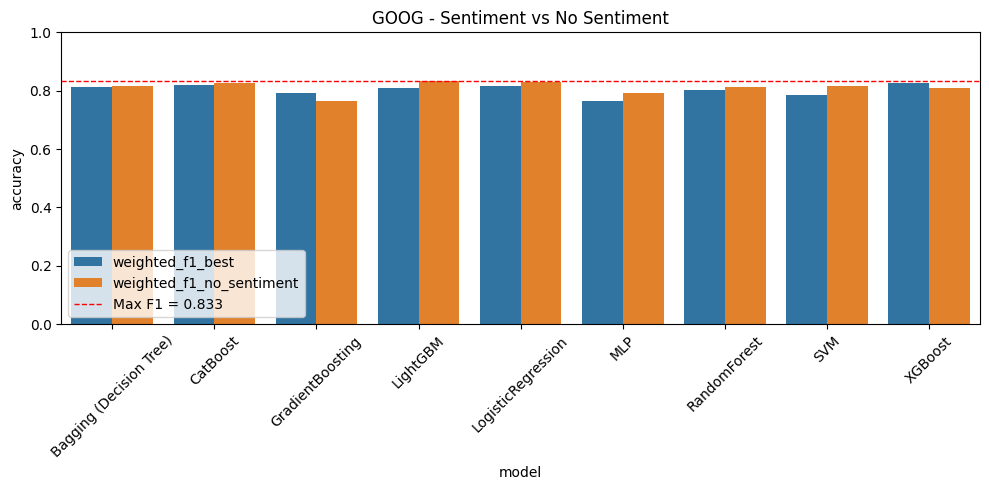

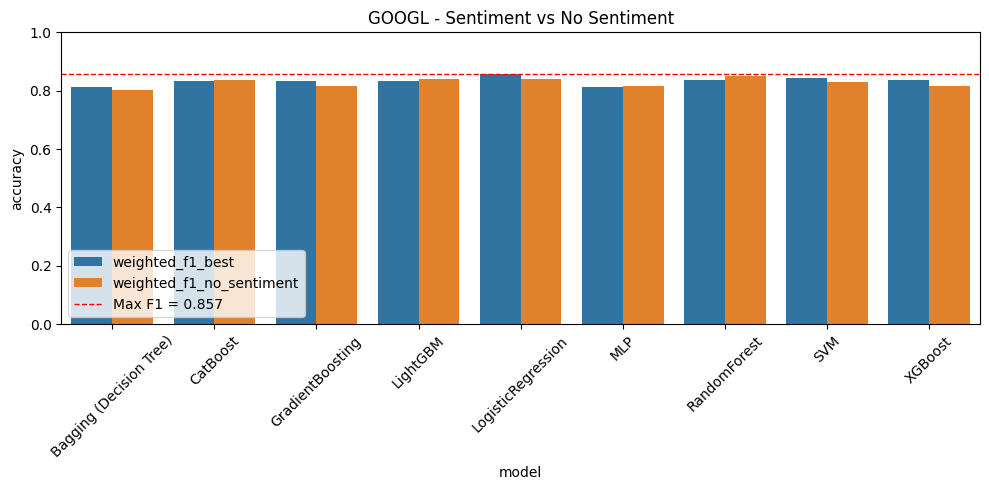

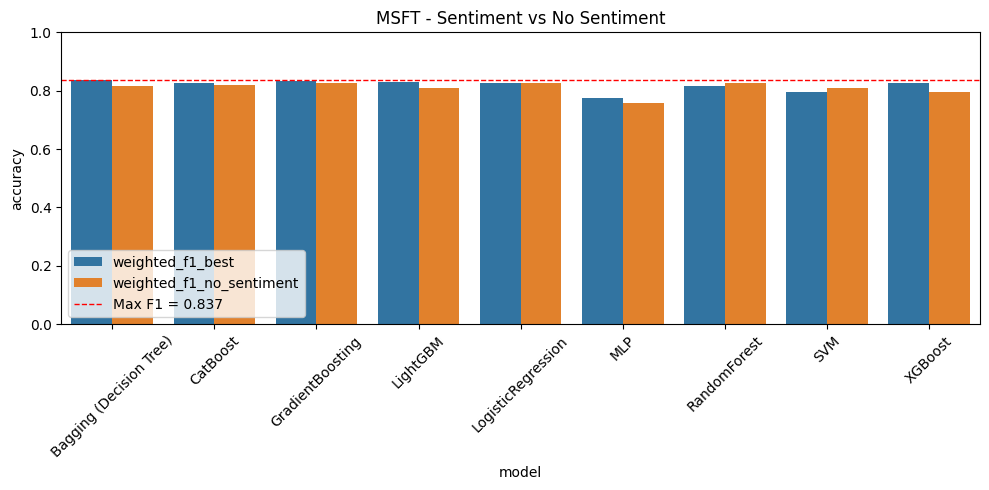

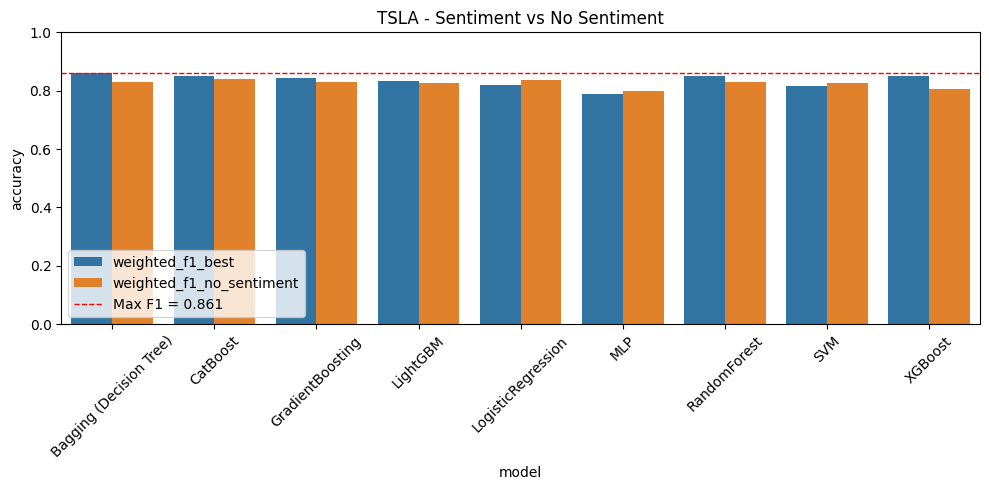

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot per ticker
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker]
    
    plt.figure(figsize=(10, 5))
    df_melted = df_ticker.melt(
        id_vars='model',
        value_vars=['weighted_f1_best', 'weighted_f1_no_sentiment'],
        var_name='Feature Set',
        value_name='accuracy'
    )

    sns.barplot(x='model', y='accuracy', hue='Feature Set', data=df_melted)
    
    # Add horizontal line at max F1 score
    max_f1 = df_melted['accuracy'].max()
    plt.axhline(max_f1, color='red', linestyle='--', linewidth=1, label=f'Max F1 = {max_f1:.3f}')
    plt.legend()

    plt.title(f"{ticker} - Sentiment vs No Sentiment")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


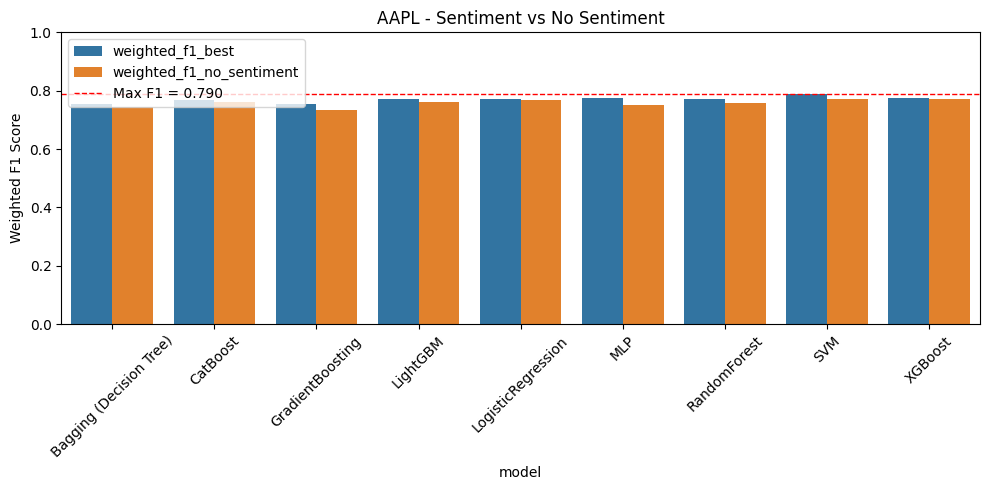

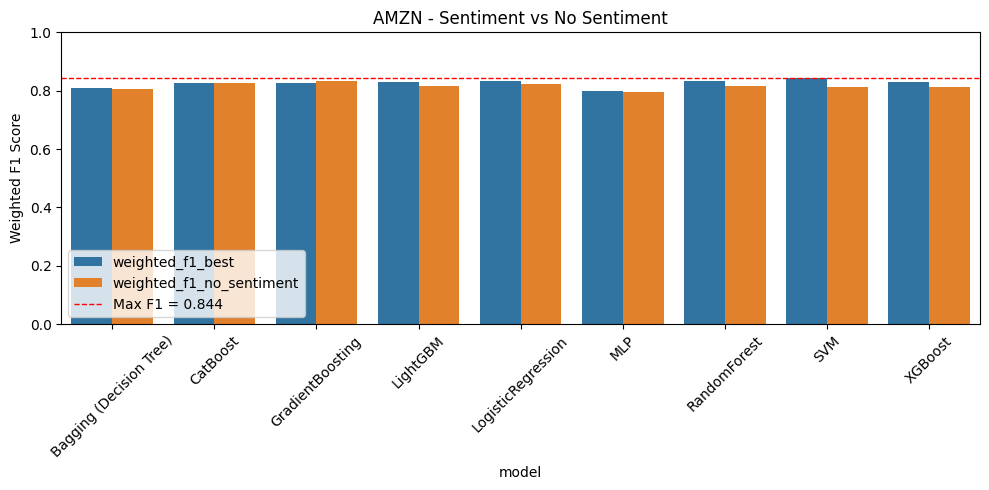

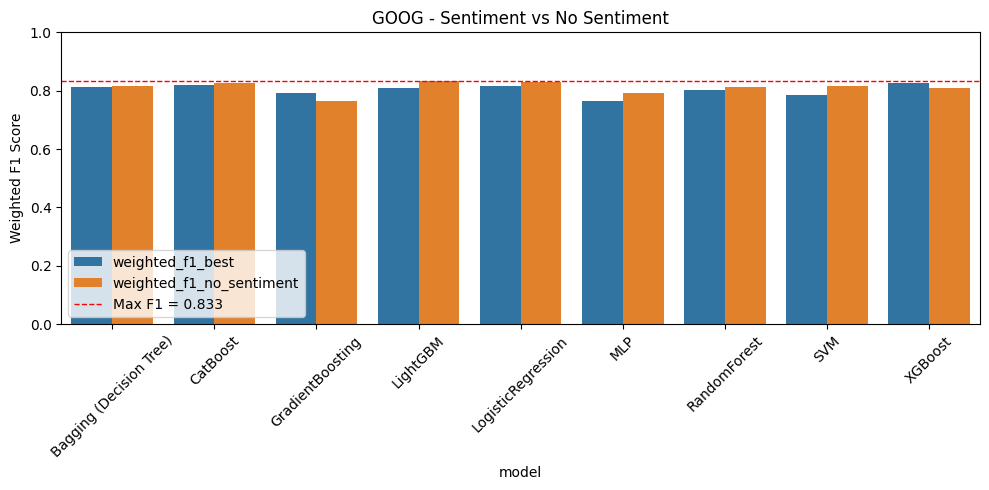

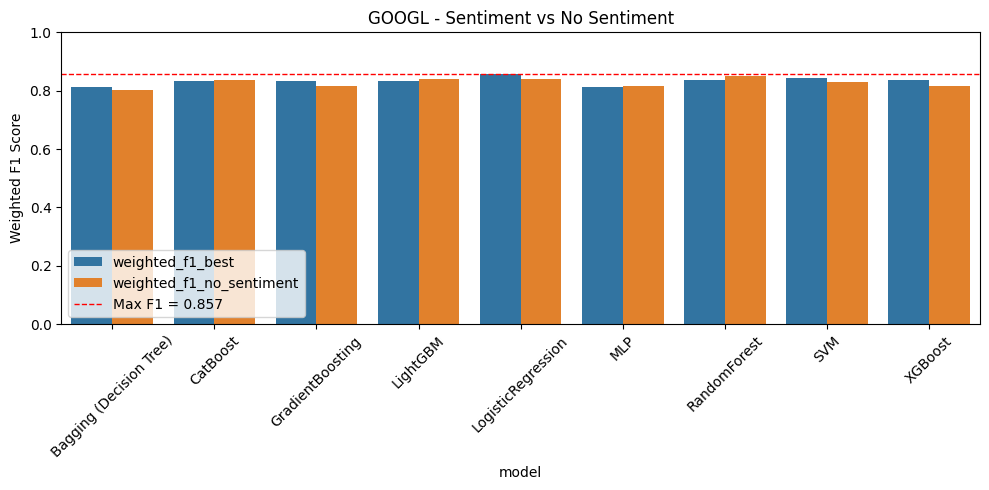

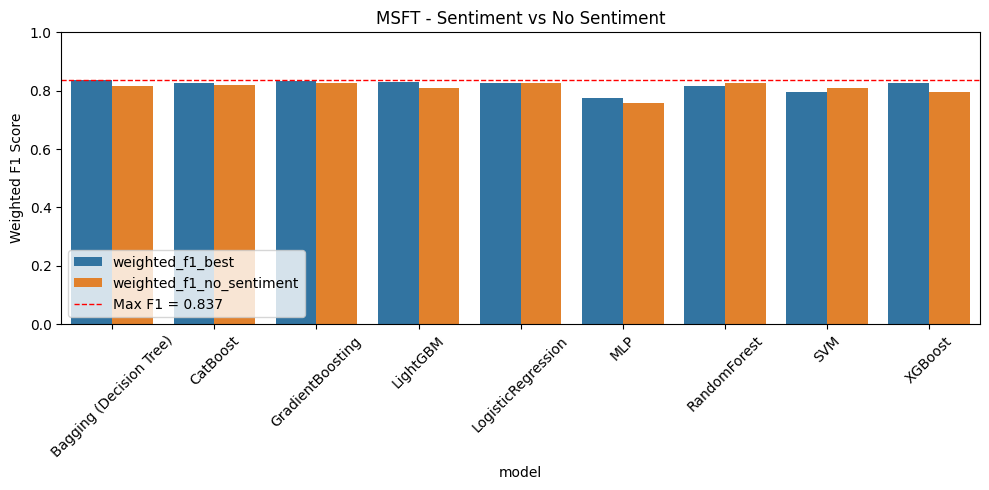

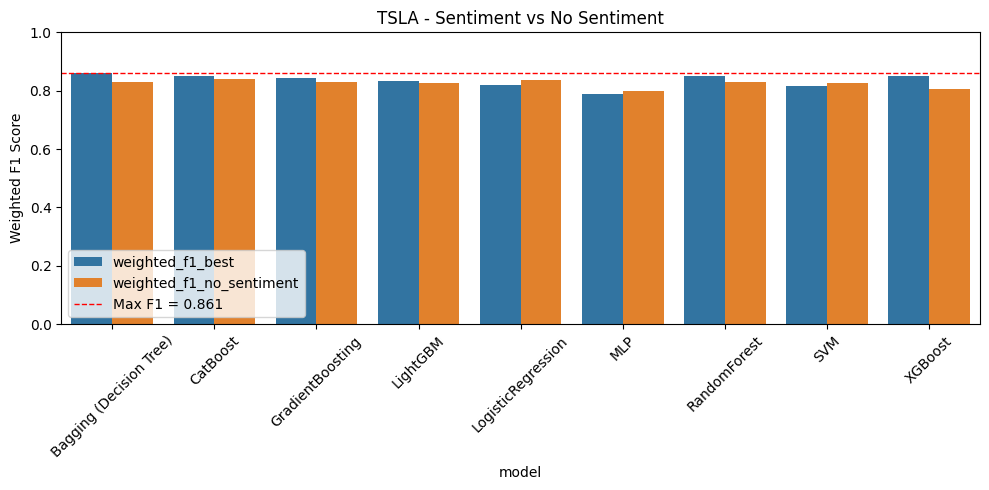

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot per ticker
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker]
    
    plt.figure(figsize=(10, 5))
    df_melted = df_ticker.melt(
        id_vars='model',
        value_vars=['weighted_f1_best', 'weighted_f1_no_sentiment'],
        var_name='Feature Set',
        value_name='Weighted F1 Score'
    )

    sns.barplot(x='model', y='Weighted F1 Score', hue='Feature Set', data=df_melted)
    
    # Add horizontal line at max F1 score
    max_f1 = df_melted['Weighted F1 Score'].max()
    plt.axhline(max_f1, color='red', linestyle='--', linewidth=1, label=f'Max F1 = {max_f1:.3f}')
    plt.legend()

    plt.title(f"{ticker} - Sentiment vs No Sentiment")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


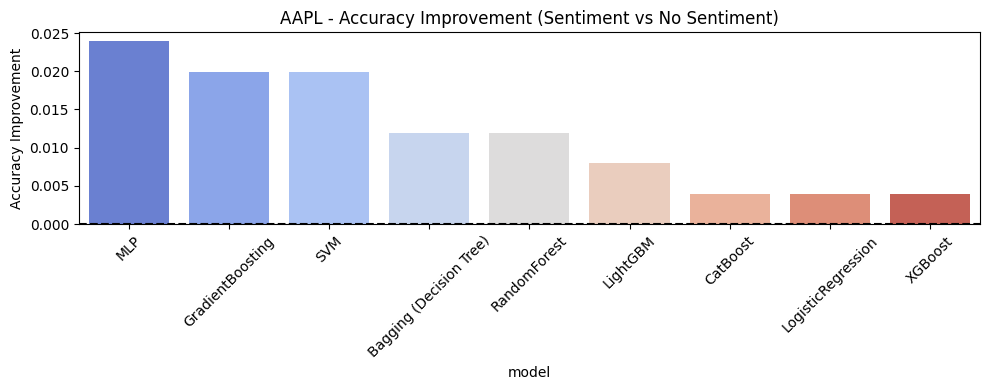

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


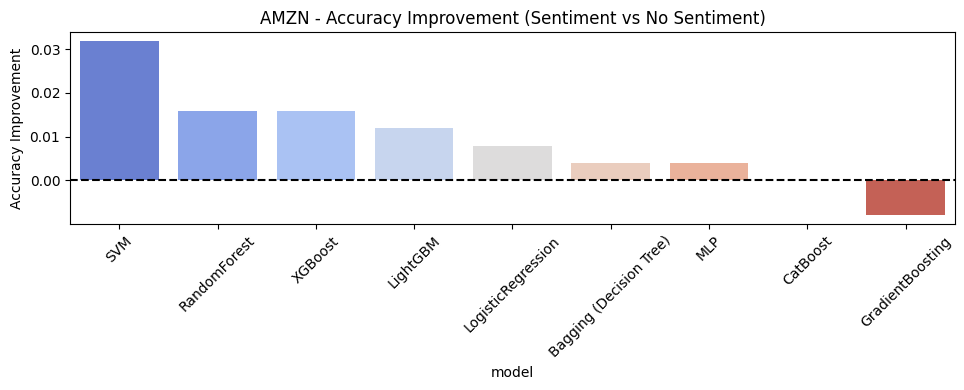

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


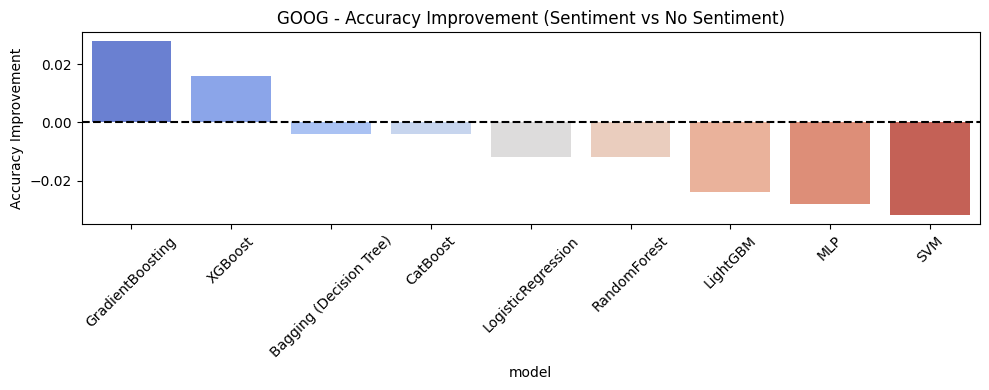

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


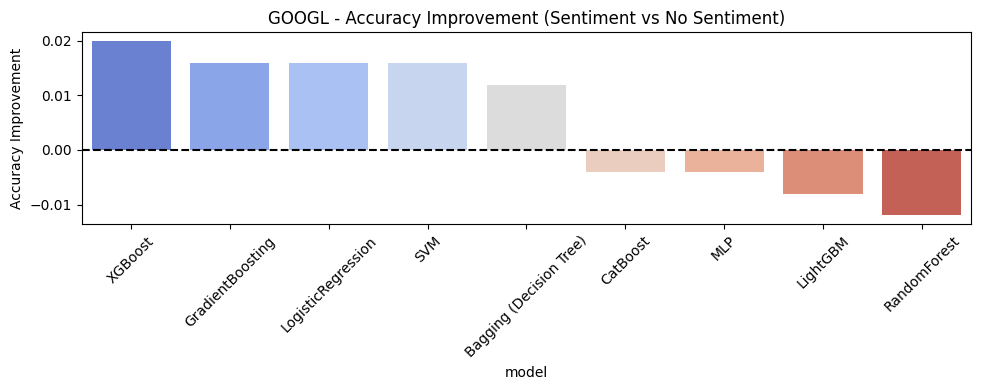

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


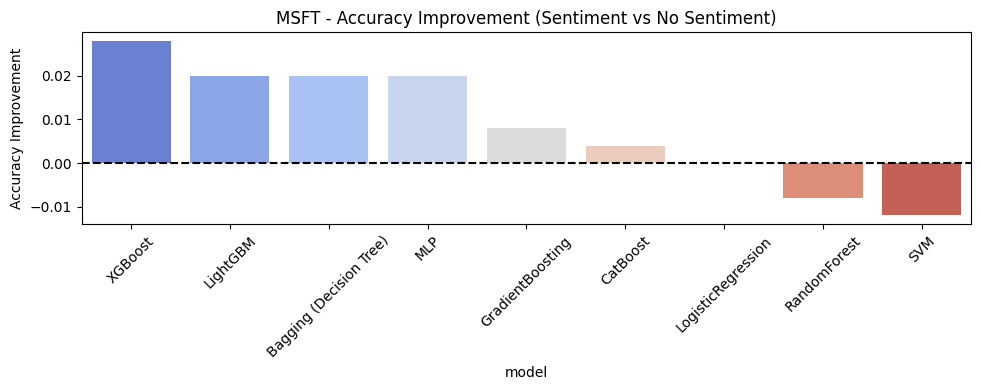

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


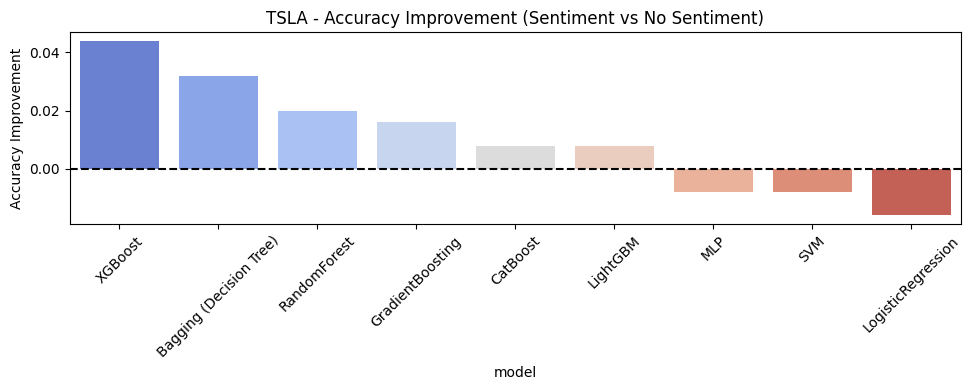

In [ ]:
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker].sort_values('accuracy_improvement', ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"{ticker} - Accuracy Improvement (Sentiment vs No Sentiment)")
    plt.ylabel('Accuracy Improvement')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/3482597618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')


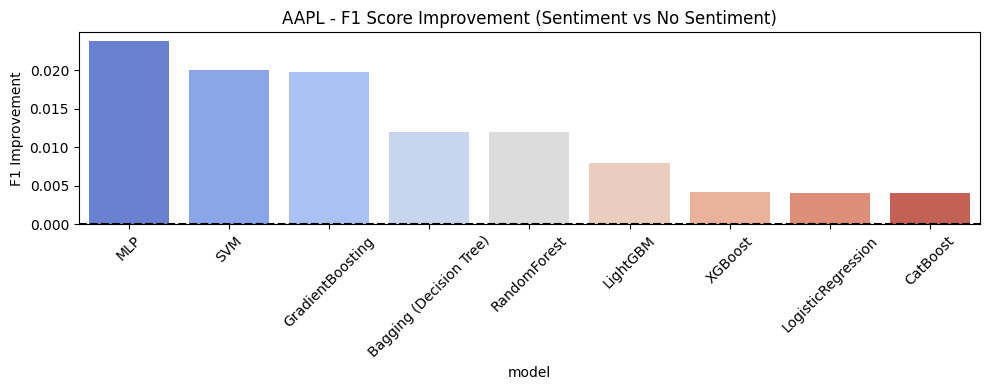

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/3482597618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')


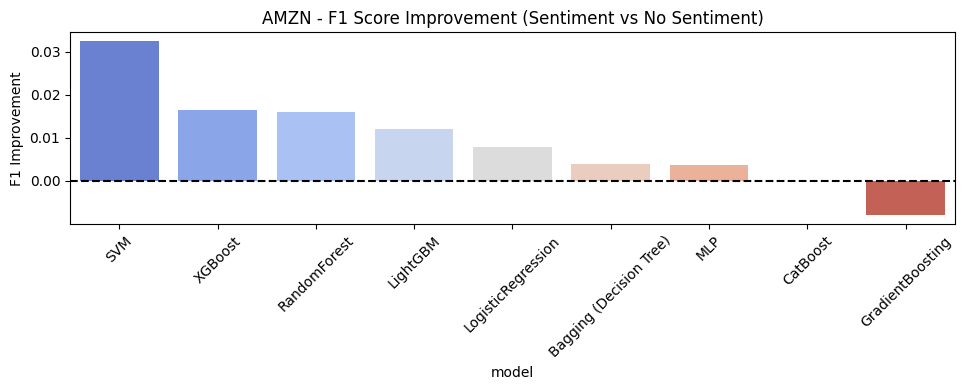

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/3482597618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')


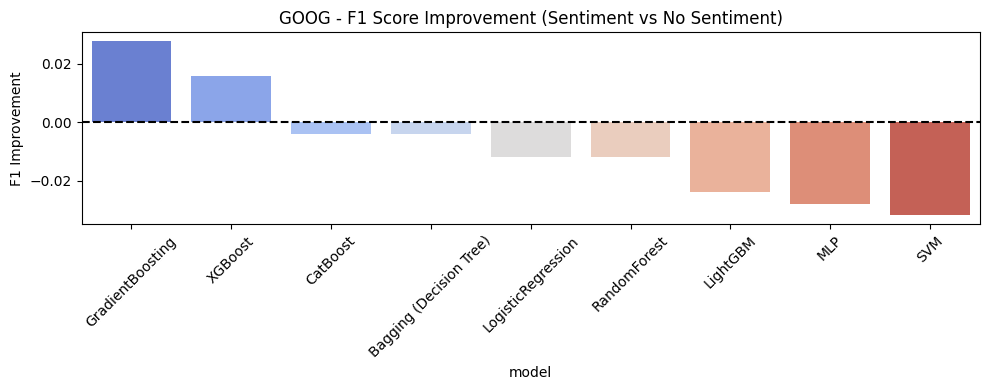

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/3482597618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')


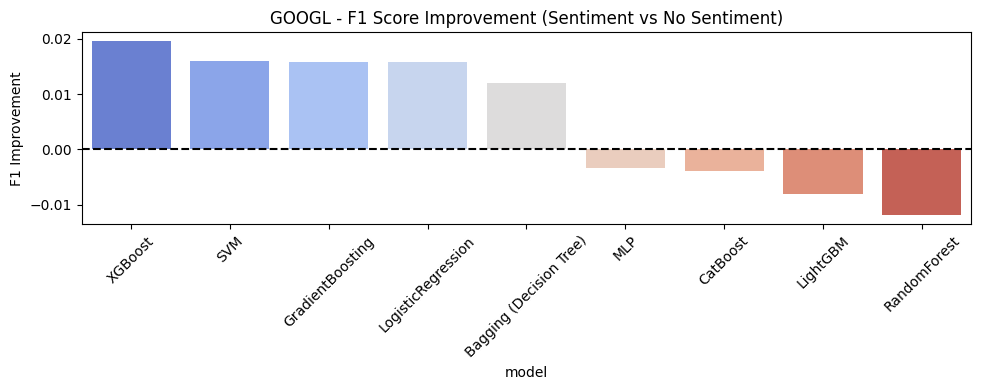

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/3482597618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')


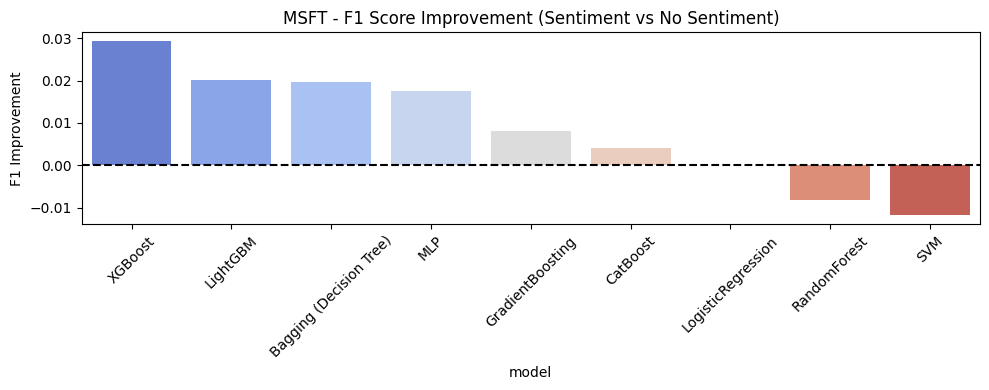

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/3482597618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')


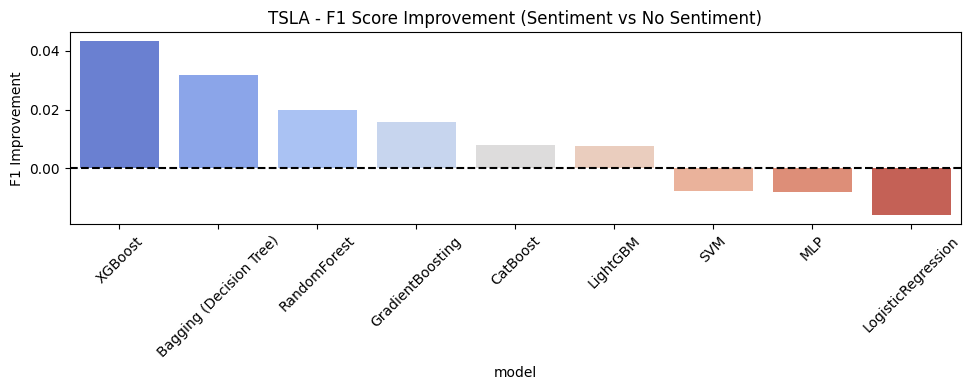

In [58]:
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker].sort_values('f1_improvement', ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(x='model', y='f1_improvement', data=df_ticker, palette='coolwarm')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"{ticker} - F1 Score Improvement (Sentiment vs No Sentiment)")
    plt.ylabel('F1 Improvement')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



###  Model Tuning and Evaluation with Time-Based Split

This script:

1. **Splits** each stock ticker's data into:

   * `train`: 2015–2017
   * `val`: 2018
   * `test`: 2019

2. **Scales** features using `StandardScaler`.

3. **Dynamically sets** `num_class` for each model based on `y_train`'s unique labels.

4. **Tunes hyperparameters** of `XGBoost`, `LightGBM`, and `CatBoost` using `RandomizedSearchCV`.

5. **Evaluates** performance on validation and test sets using `weighted F1` and `accuracy`.

6. **Saves** the best models to disk with `joblib`.

7. **Returns** a DataFrame summarizing the results.




In [59]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import joblib
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

def tune_and_save_models(df, feature_sets, target_label, output_dir="saved_models/"):
    results = []

    for ticker in df['ticker_symbol'].unique():
        df_ticker = df[df['ticker_symbol'] == ticker].copy().sort_values('date')

        # Time-based split
        train = df_ticker[(df_ticker['date'] >= '2015-01-01') & (df_ticker['date'] <= '2017-12-31')]
        val = df_ticker[(df_ticker['date'] >= '2018-01-01') & (df_ticker['date'] <= '2018-12-31')]
        test = df_ticker[(df_ticker['date'] >= '2019-01-01') & (df_ticker['date'] <= '2019-12-31')]

        if len(train) < 100 or len(test) < 50:
            continue

        for feat_name, feat_cols in feature_sets.items():
            X_train, y_train = train[feat_cols], train[target_label]
            X_val, y_val = val[feat_cols], val[target_label]
            X_test, y_test = test[feat_cols], test[target_label]

            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)

            for model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
                try:
                    # Binary Classification Models
                    if model_name == 'XGBoost':
                        model = XGBClassifier(
                            objective='binary:logistic',
                            eval_metric='logloss',
                            use_label_encoder=False,
                            verbosity=0,
                            random_state=42
                        )
                        param_dist = {
                            'n_estimators': [100, 200],
                            'max_depth': [3, 5, 7],
                            'learning_rate': [0.01, 0.1, 0.2]
                        }

                    elif model_name == 'LightGBM':
                        model = LGBMClassifier(
                            objective='binary',
                            verbose=-1,
                            random_state=42
                        )
                        param_dist = {
                            'n_estimators': [50, 100, 150],
                            'max_depth': [5, 10, -1],
                            'learning_rate': [0.01, 0.1, 0.2]
                        }

                    elif model_name == 'CatBoost':
                        model = CatBoostClassifier(
                            loss_function='Logloss',
                            verbose=0,
                            random_state=42
                        )
                        param_dist = {
                            'depth': [4, 6, 8],
                            'learning_rate': [0.01, 0.1, 0.2],
                            'iterations': [100, 200]
                        }

                    # Randomized Search for Hyperparameter Tuning
                    search = RandomizedSearchCV(
                        model, param_distributions=param_dist,
                        n_iter=10, cv=3, scoring='f1_weighted',
                        n_jobs=-1, random_state=42
                    )
                    search.fit(X_train_scaled, y_train)

                    best_model = search.best_estimator_
                    val_pred = best_model.predict(X_val_scaled)
                    test_pred = best_model.predict(X_test_scaled)

                    val_report = classification_report(y_val, val_pred, output_dict=True, zero_division=0)
                    test_report = classification_report(y_test, test_pred, output_dict=True, zero_division=0)

                    model_filename = f"{output_dir}{ticker}_{model_name}_{feat_name}.joblib"
                    joblib.dump(best_model, model_filename)

                    results.append({
                        'ticker': ticker,
                        'feature_set': feat_name,
                        'model': model_name,
                        'val_f1': val_report['weighted avg']['f1-score'],
                        'test_f1': test_report['weighted avg']['f1-score'],
                        'val_acc': val_report['accuracy'],
                        'test_acc': test_report['accuracy'],
                        'best_params': search.best_params_,
                        'saved_model': model_filename
                    })

                except Exception as e:
                    print(f"Failed on {ticker} - {feat_name} - {model_name}: {e}")

    return pd.DataFrame(results)


In [60]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
# import joblib
# import pandas as pd
# import numpy as np

# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier

# def tune_and_save_models(df, feature_sets, target_label, output_dir="saved_models/"):
#     results = []

#     for ticker in df['ticker_symbol'].unique():
#         df_ticker = df[df['ticker_symbol'] == ticker].copy().sort_values('date')

#         # Time-based split
#         train = df_ticker[(df_ticker['date'] >= '2015-01-01') & (df_ticker['date'] <= '2017-12-31')]
#         val = df_ticker[(df_ticker['date'] >= '2018-01-01') & (df_ticker['date'] <= '2018-12-31')]
#         test = df_ticker[(df_ticker['date'] >= '2019-01-01') & (df_ticker['date'] <= '2019-12-31')]

#         if len(train) < 100 or len(test) < 50:
#             continue

#         for feat_name, feat_cols in feature_sets.items():
#             X_train, y_train = train[feat_cols], train[target_label]
#             X_val, y_val = val[feat_cols], val[target_label]
#             X_test, y_test = test[feat_cols], test[target_label]

#             # Scale features
#             scaler = StandardScaler()
#             X_train_scaled = scaler.fit_transform(X_train)
#             X_val_scaled = scaler.transform(X_val)
#             X_test_scaled = scaler.transform(X_test)

#             # Detect number of classes in current training fold
#             unique_classes = np.unique(y_train)
#             num_classes = len(unique_classes)

#             for model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
#                 try:
#                     # Recreate models with correct num_class per ticker
#                     if model_name == 'XGBoost':
#                         model = XGBClassifier(
#                             objective='multi:softprob',
#                             num_class=num_classes,
#                             eval_metric='mlogloss',
#                             use_label_encoder=False,
#                             verbosity=0,
#                             random_state=42
#                         )
#                         param_dist = {
#                             'n_estimators': [100, 200],
#                             'max_depth': [3, 5, 7],
#                             'learning_rate': [0.01, 0.1, 0.2]
#                         }

#                     elif model_name == 'LightGBM':
#                         model = LGBMClassifier(
#                             objective='multiclass',
#                             num_class=num_classes,
#                             verbose=-1,
#                             random_state=42
#                         )
#                         param_dist = {
#                             'n_estimators': [50, 100, 150],
#                             'max_depth': [5, 10, -1],
#                             'learning_rate': [0.01, 0.1, 0.2]
#                         }

#                     elif model_name == 'CatBoost':
#                         model = CatBoostClassifier(
#                             loss_function='MultiClass',
#                             verbose=0,
#                             random_state=42
#                         )
#                         param_dist = {
#                             'depth': [4, 6, 8],
#                             'learning_rate': [0.01, 0.1, 0.2],
#                             'iterations': [100, 200]
#                         }

#                     # Tune
#                     search = RandomizedSearchCV(
#                         model, param_distributions=param_dist,
#                         n_iter=10, cv=3, scoring='f1_weighted',
#                         n_jobs=-1, random_state=42
#                     )
#                     search.fit(X_train_scaled, y_train)

#                     best_model = search.best_estimator_
#                     val_pred = best_model.predict(X_val_scaled)
#                     test_pred = best_model.predict(X_test_scaled)

#                     val_report = classification_report(y_val, val_pred, output_dict=True, zero_division=0)
#                     test_report = classification_report(y_test, test_pred, output_dict=True, zero_division=0)

#                     model_filename = f"{output_dir}{ticker}_{model_name}_{feat_name}.joblib"
#                     joblib.dump(best_model, model_filename)

#                     results.append({
#                         'ticker': ticker,
#                         'feature_set': feat_name,
#                         'model': model_name,
#                         'val_f1': val_report['weighted avg']['f1-score'],
#                         'test_f1': test_report['weighted avg']['f1-score'],
#                         'val_acc': val_report['accuracy'],
#                         'test_acc': test_report['accuracy'],
#                         'best_params': search.best_params_,
#                         'saved_model': model_filename
#                     })

#                 except Exception as e:
#                     print(f"Failed on {ticker} - {feat_name} - {model_name}: {e}")

#     return pd.DataFrame(results)


In [61]:
results_df_tuned = tune_and_save_models(df, feature_sets, target_label)

joblib.dump(results_df_tuned, 'saved_models/model_results_df.joblib')


/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/valida

['saved_models/model_results_df.joblib']

In [95]:
import joblib

# Load the saved DataFrame
results_df_tuned = joblib.load('saved_models/model_results_df.joblib')

# (Optional) Check the first few rows
print(results_df_tuned.head(6))


  ticker              feature_set     model    val_f1   test_f1  val_acc  \
0   AAPL     open_sentiment_basic   XGBoost  0.812497  0.742872    0.812   
1   AAPL     open_sentiment_basic  LightGBM  0.816143  0.765101    0.816   
2   AAPL     open_sentiment_basic  CatBoost  0.828423  0.761817    0.828   
3   AAPL  open_sentiment_weighted   XGBoost  0.767554  0.786300    0.768   
4   AAPL  open_sentiment_weighted  LightGBM  0.832238  0.764771    0.832   
5   AAPL  open_sentiment_weighted  CatBoost  0.828423  0.761817    0.828   

   test_acc                                        best_params  \
0  0.741036  {'n_estimators': 200, 'max_depth': 5, 'learnin...   
1  0.764940  {'n_estimators': 50, 'max_depth': 5, 'learning...   
2  0.760956  {'learning_rate': 0.01, 'iterations': 100, 'de...   
3  0.784861  {'n_estimators': 200, 'max_depth': 3, 'learnin...   
4  0.764940  {'n_estimators': 150, 'max_depth': -1, 'learni...   
5  0.760956  {'learning_rate': 0.01, 'iterations': 100, 'de...   

    

In [97]:
# results_df= results_df_tuned['ticker', 'feature_set','model','val_acc','test_acc', 'val_f1', 'test_f1' ]
results_df = results_df_tuned[['ticker', 'feature_set','model','val_acc','test_acc', 'val_f1', 'test_f1']]


# 1. Filter & extract best sentiment-based and no-sentiment results
with_sentiment = results_df[~results_df['feature_set'].str.endswith('no_sentiment')]
best_results = (
    with_sentiment
    .groupby(['ticker', 'model'], as_index=False)
    .apply(lambda g: g.loc[g['test_acc'].idxmax()], include_groups=False)
    .reset_index(drop=True)
)

no_sentiment = results_df[results_df['feature_set'].str.endswith('no_sentiment')]

# 2. Merge best with corresponding no-sentiment
comparison_df = pd.merge(
    best_results,
    no_sentiment,
    on=['ticker', 'model'],
    suffixes=('_best', '_no_sentiment')
)

# 3. Calculate improvement metrics
comparison_df['accuracy_improvement'] = comparison_df['val_acc_best'] - comparison_df['val_acc_no_sentiment']
comparison_df['f1_improvement'] = comparison_df['val_f1_best'] - comparison_df['val_f1_no_sentiment']

# # 4. Rename columns for clarity (optional)
# comparison_df.rename(columns={
#     'val_acc_best': 'accuracy_best',
#     'val_f1_best': 'weighted_f1_best',
#     'val_acc_no_sentiment': 'accuracy_no_sentiment',
#     'val_f1_no_sentiment': 'weighted_f1_no_sentiment'
# }, inplace=True)


In [98]:
comparison_df

,ticker,model,feature_set_best,val_acc_best,test_acc_best,val_f1_best,test_f1_best,feature_set_no_sentiment,val_acc_no_sentiment,test_acc_no_sentiment,val_f1_no_sentiment,test_f1_no_sentiment,accuracy_improvement,f1_improvement
0,AAPL,CatBoost,open_sentiment_basic,0.828000,0.760956,0.828423,0.761817,open_no_sentiment,0.828000,0.756972,0.828456,0.757965,0.000000,-3.270859e-05
1,AAPL,LightGBM,open_sentiment_basic,0.816000,0.764940,0.816143,0.765101,open_no_sentiment,0.824000,0.768924,0.824340,0.769233,-0.008000,-8.197470e-03
2,AAPL,XGBoost,open_sentiment_weighted,0.768000,0.784861,0.767554,0.786300,open_no_sentiment,0.792000,0.756972,0.790800,0.757829,-0.024000,-2.324555e-02
3,AMZN,CatBoost,open_sentiment_basic,0.836653,0.816733,0.836945,0.816634,open_no_sentiment,0.844622,0.816733,0.844845,0.816634,-0.007968,-7.899666e-03
4,AMZN,LightGBM,open_sentiment_basic,0.856574,0.824701,0.856670,0.824185,open_no_sentiment,0.864542,0.824701,0.864542,0.824348,-0.007968,-7.871837e-03
5,AMZN,XGBoost,open_sentiment_basic,0.848606,0.832669,0.848789,0.832579,open_no_sentiment,0.856574,0.812749,0.856670,0.812288,-0.007968,-7.880733e-03
6,GOOG,CatBoost,open_sentiment_basic,0.868526,0.828685,0.868609,0.828849,open_no_sentiment,0.884462,0.820717,0.884502,0.821077,-0.015936,-1.589304e-02
7,GOOG,LightGBM,open_sentiment_basic,0.876494,0.820717,0.876573,0.820975,open_no_sentiment,0.872510,0.820717,0.872449,0.820111,0.003984,4.123485e-03
8,GOOG,XGBoost,open_sentiment_weighted,0.880478,0.816733,0.880520,0.817083,open_no_sentiment,0.872510,0.816733,0.872571,0.817112,0.007968,7.949228e-03
9,GOOGL,CatBoost,open_sentiment_weighted,0.908367,0.848606,0.908367,0.848870,open_no_sentiment,0.896414,0.848606,0.896395,0.848823,0.011952,1.197192e-02


/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


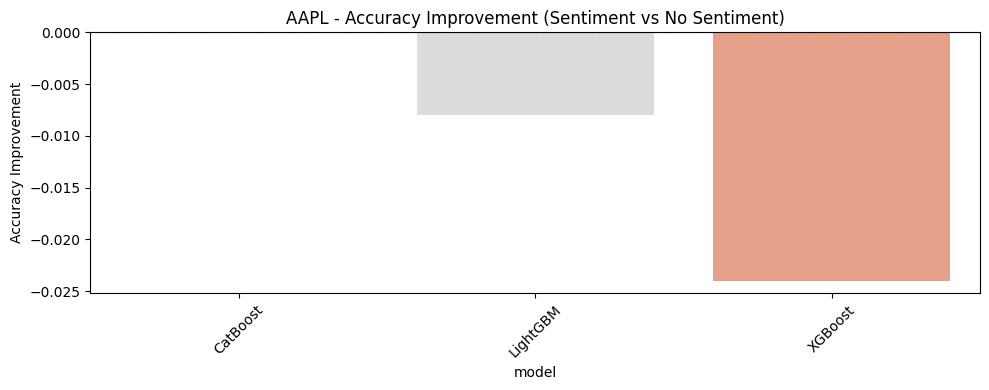

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


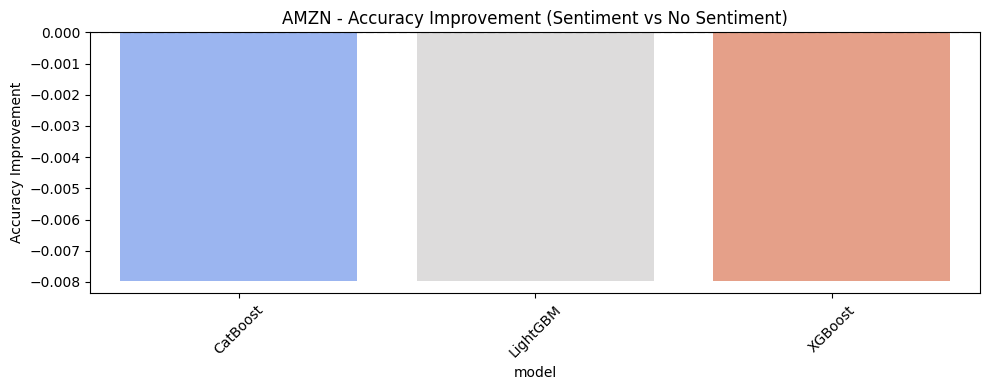

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


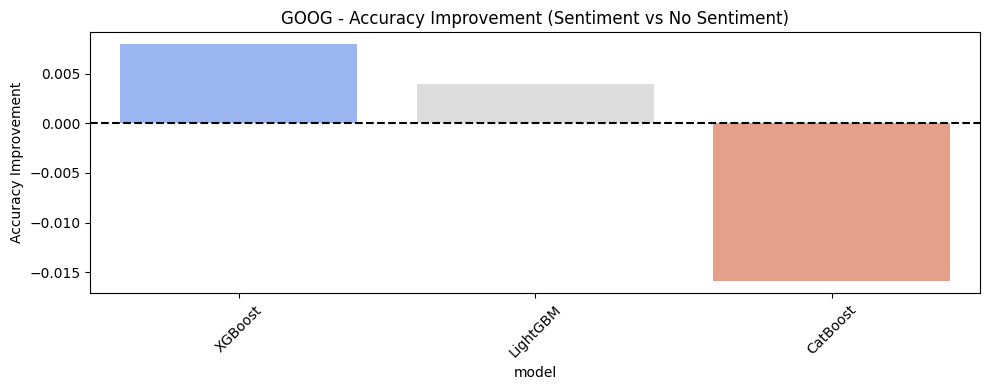

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


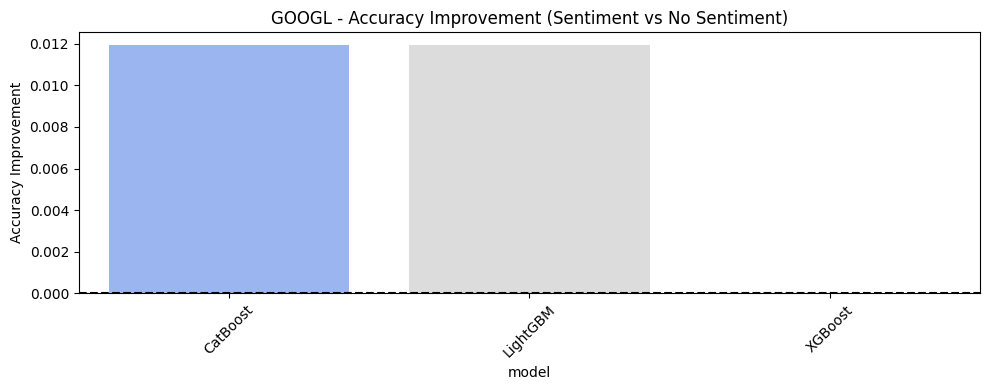

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


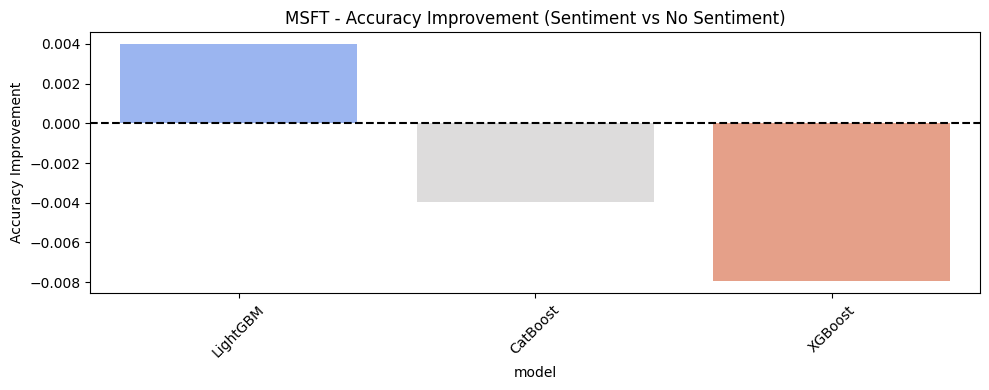

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_51448/2582069492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')


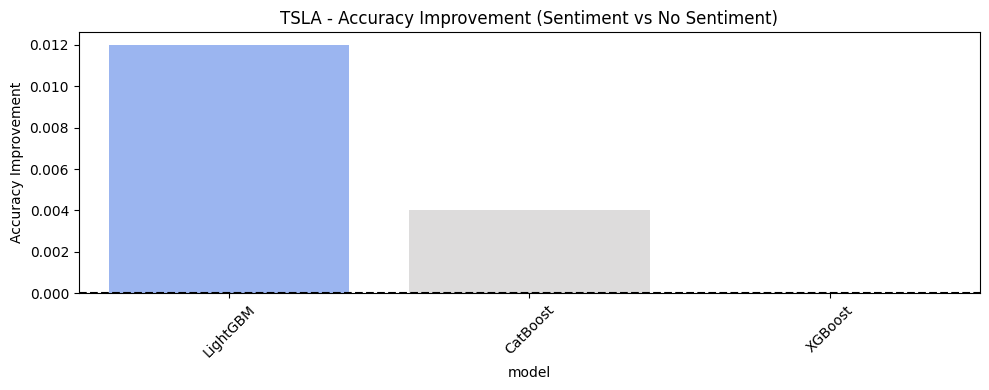

In [99]:
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker].sort_values('accuracy_improvement', ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(x='model', y='accuracy_improvement', data=df_ticker, palette='coolwarm')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"{ticker} - Accuracy Improvement (Sentiment vs No Sentiment)")
    plt.ylabel('Accuracy Improvement')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



--- Results for Ticker: AAPL ---
ticker    model        feature_set_best  test_acc_best  test_f1_best feature_set_no_sentiment  test_acc_no_sentiment  test_f1_no_sentiment  accuracy_improvement  f1_improvement
  AAPL  XGBoost open_sentiment_weighted       0.784861      0.786300        open_no_sentiment               0.756972              0.757829              0.027888        0.028471
  AAPL CatBoost    open_sentiment_basic       0.760956      0.761817        open_no_sentiment               0.756972              0.757965              0.003984        0.003853
  AAPL LightGBM    open_sentiment_basic       0.764940      0.765101        open_no_sentiment               0.768924              0.769233             -0.003984       -0.004132

--- Results for Ticker: AMZN ---
ticker    model     feature_set_best  test_acc_best  test_f1_best feature_set_no_sentiment  test_acc_no_sentiment  test_f1_no_sentiment  accuracy_improvement  f1_improvement
  AMZN  XGBoost open_sentiment_basic       0.83266

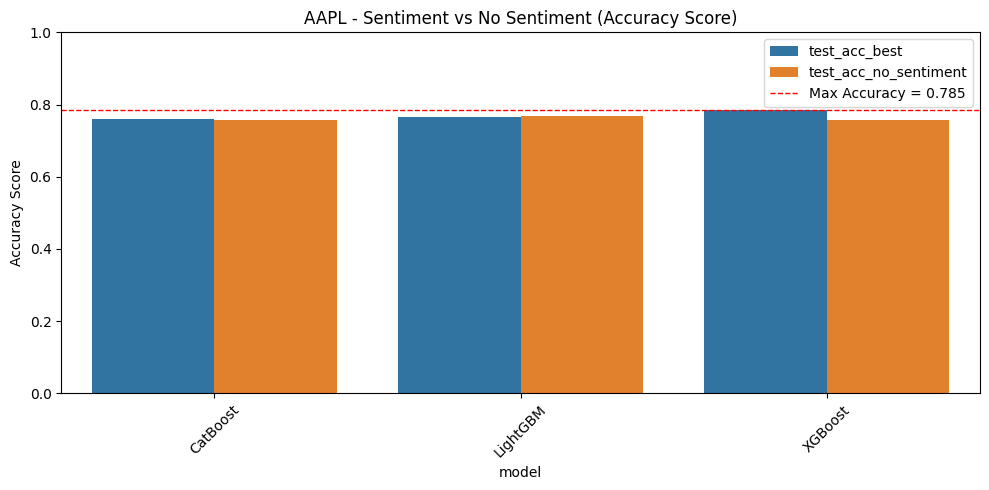

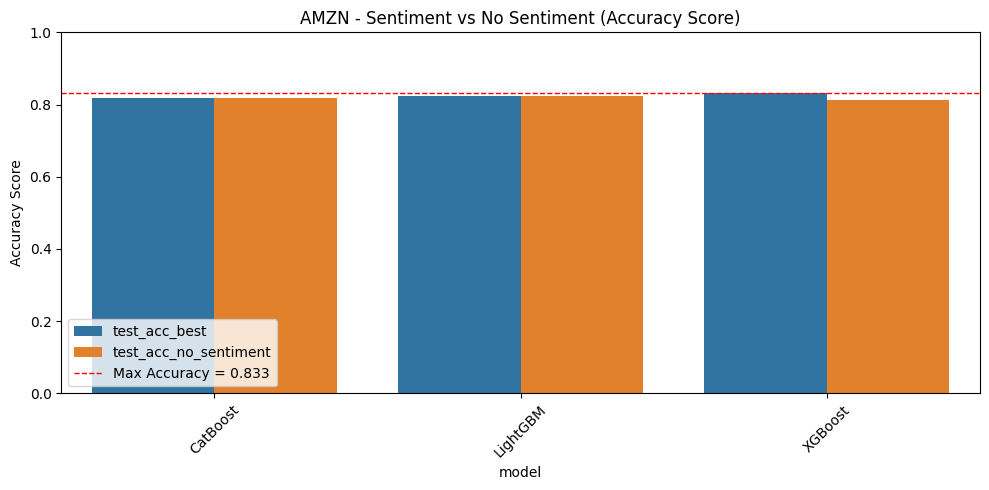

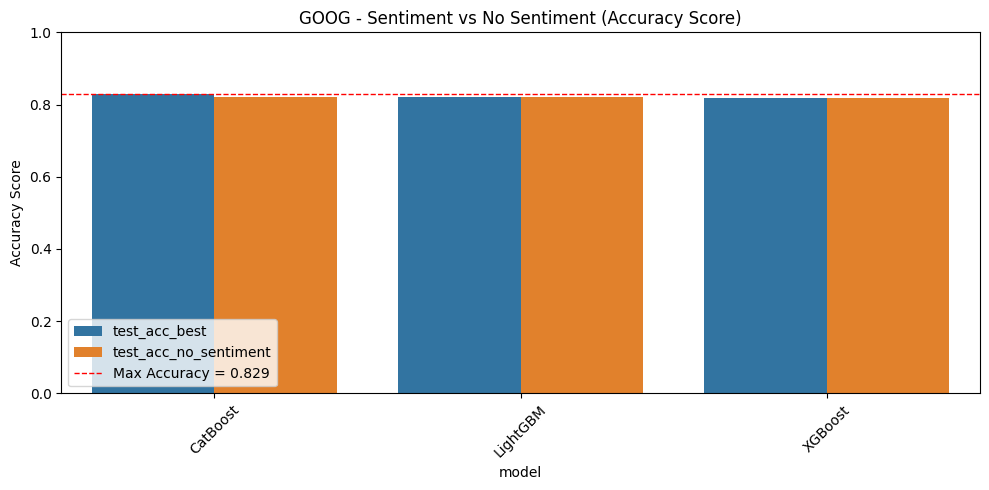

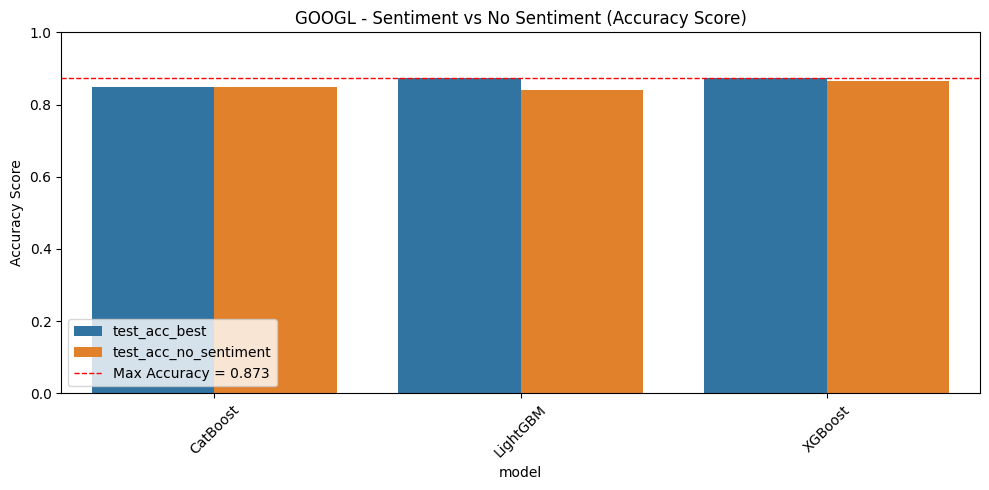

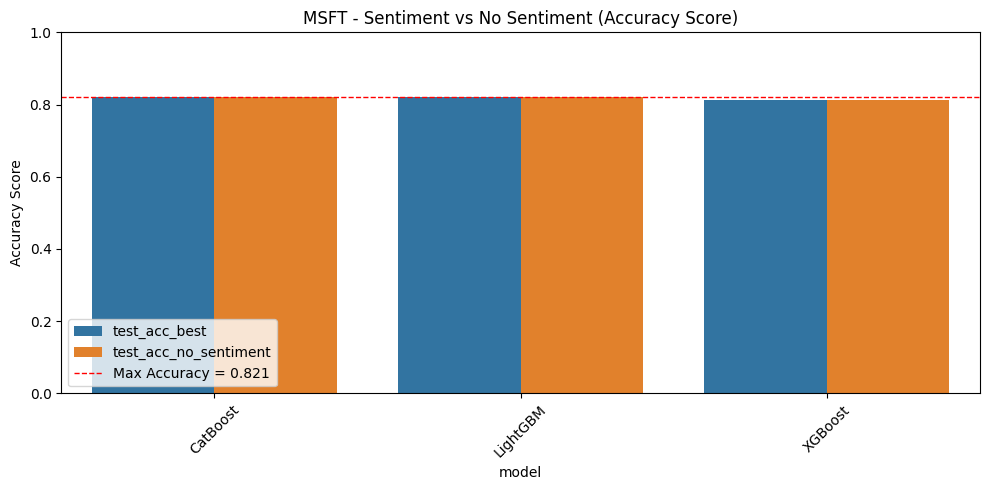

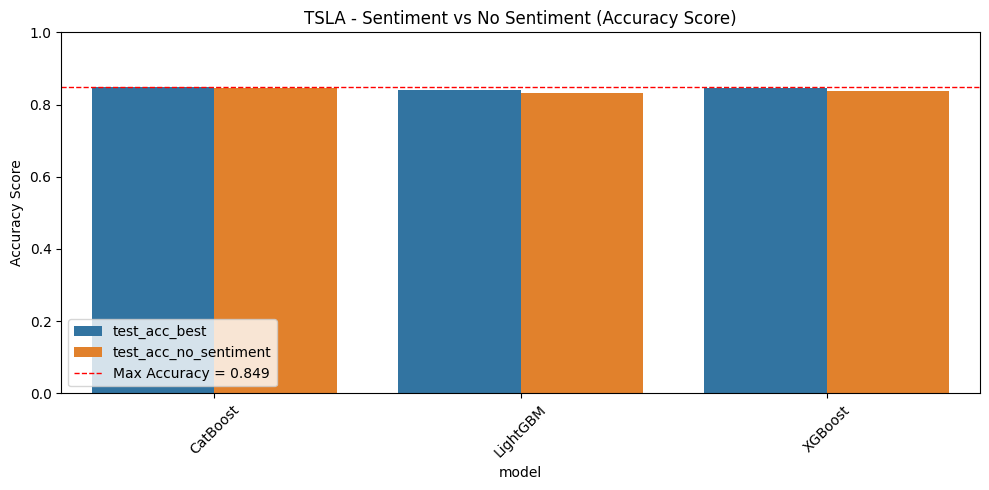

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Start with tuned results
# results_df = results_df_tuned.copy()
results_df = results_df_tuned[['ticker', 'feature_set','model','val_acc','test_acc', 'val_f1', 'test_f1']]

# Step 1: Keep only models that use sentiment
with_sentiment = results_df[~results_df['feature_set'].str.endswith('no_sentiment')]

# Step 2: Best (highest test_f1) per (ticker, model)
best_results = (
    with_sentiment
    .groupby(['ticker', 'model'], as_index=False)
    .apply(lambda g: g.loc[g['test_acc'].idxmax()], include_groups=False)
    .reset_index(drop=True)
)

# Step 3: Get corresponding no_sentiment results
no_sentiment = results_df[results_df['feature_set'].str.endswith('no_sentiment')]

# Step 4: Merge to compare sentiment vs no-sentiment
comparison_df = pd.merge(
    best_results,
    no_sentiment,
    on=['ticker', 'model'],
    suffixes=('_best', '_no_sentiment')
)

# Step 5: Calculate improvements
comparison_df['accuracy_improvement'] = comparison_df['test_acc_best'] - comparison_df['test_acc_no_sentiment']
comparison_df['f1_improvement'] = comparison_df['test_f1_best'] - comparison_df['test_f1_no_sentiment']

# Optional display settings
pd.set_option('display.max_rows', 160)
pd.set_option('display.max_columns', None)

# Output columns of interest
cols = [
    'ticker', 'model',
    'feature_set_best', 'test_acc_best', 'test_f1_best',
    'feature_set_no_sentiment', 'test_acc_no_sentiment', 'test_f1_no_sentiment',
    'accuracy_improvement', 'f1_improvement'
]

# Print per-ticker comparison tables
for ticker in comparison_df['ticker'].unique():
    print(f"\n--- Results for Ticker: {ticker} ---")
    df_sorted = comparison_df[comparison_df['ticker'] == ticker].sort_values(by='accuracy_improvement', ascending=False)
    print(df_sorted[cols].to_string(index=False))

# Plot comparison barplots
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker]

    plt.figure(figsize=(10, 5))
    df_melted = df_ticker.melt(
        id_vars='model',
        value_vars=['test_acc_best', 'test_acc_no_sentiment'],
        var_name='Feature Set',
        value_name='Accuracy Score'
    )

    sns.barplot(x='model', y='Accuracy Score', hue='Feature Set', data=df_melted)

    max_f1 = df_melted['Accuracy Score'].max()
    plt.axhline(max_f1, color='red', linestyle='--', linewidth=1, label=f'Max Accuracy = {max_f1:.3f}')
    plt.legend()

    plt.title(f"{ticker} - Sentiment vs No Sentiment (Accuracy Score)")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()



--- Results for Ticker: AAPL ---
ticker    model        feature_set_best  test_acc_best  test_f1_best feature_set_no_sentiment  test_acc_no_sentiment  test_f1_no_sentiment  accuracy_improvement  f1_improvement
  AAPL  XGBoost open_sentiment_weighted       0.784861      0.786300        open_no_sentiment               0.756972              0.757829              0.027888        0.028471
  AAPL CatBoost    open_sentiment_basic       0.760956      0.761817        open_no_sentiment               0.756972              0.757965              0.003984        0.003853
  AAPL LightGBM    open_sentiment_basic       0.764940      0.765101        open_no_sentiment               0.768924              0.769233             -0.003984       -0.004132

--- Results for Ticker: AMZN ---
ticker    model     feature_set_best  test_acc_best  test_f1_best feature_set_no_sentiment  test_acc_no_sentiment  test_f1_no_sentiment  accuracy_improvement  f1_improvement
  AMZN  XGBoost open_sentiment_basic       0.83266

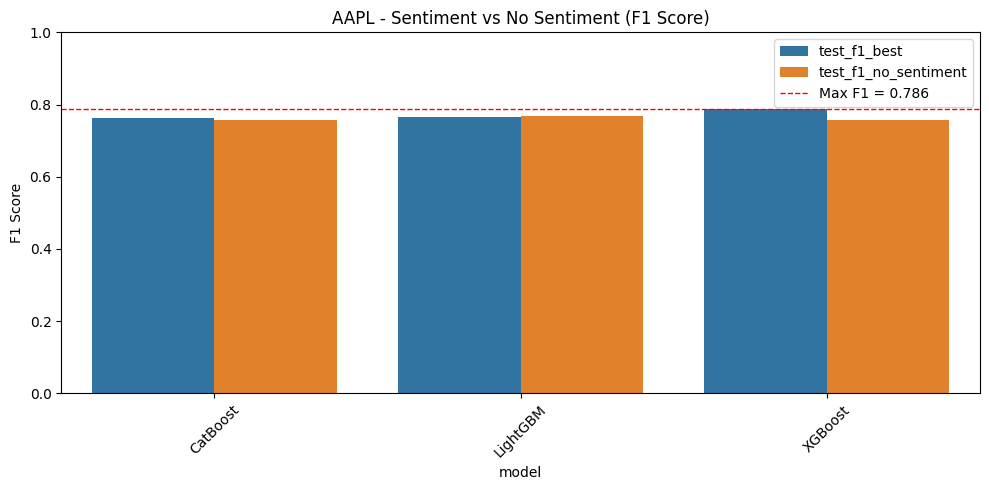

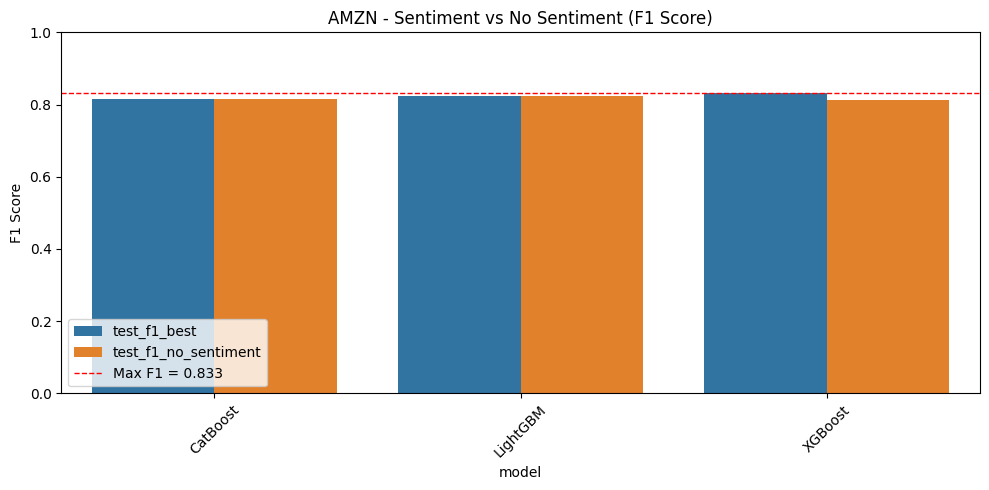

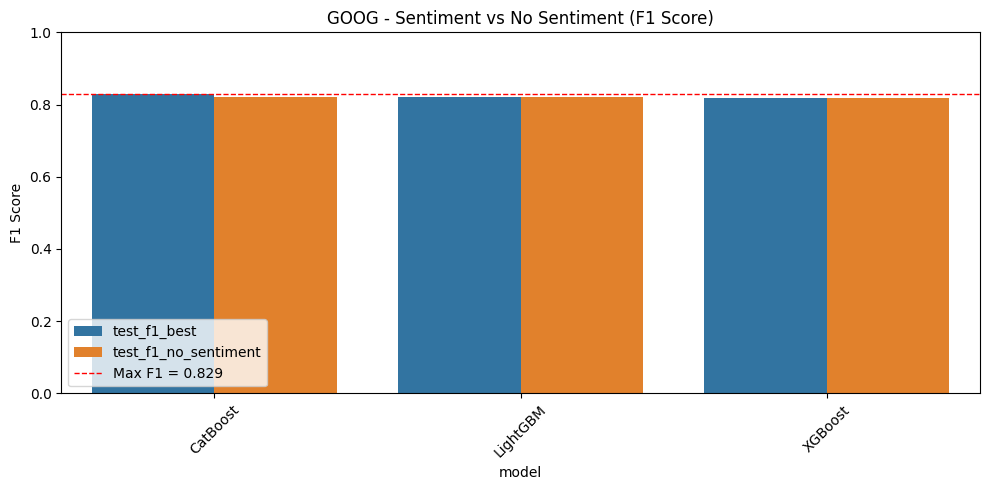

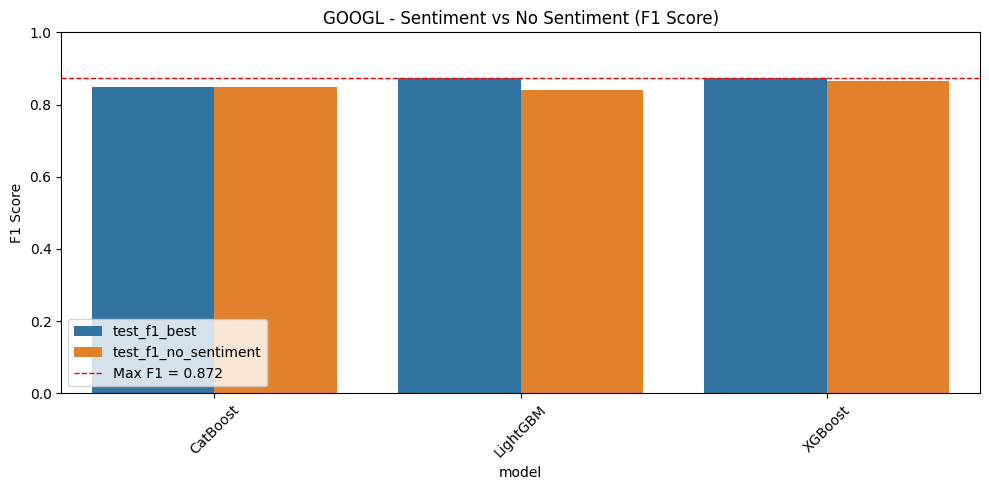

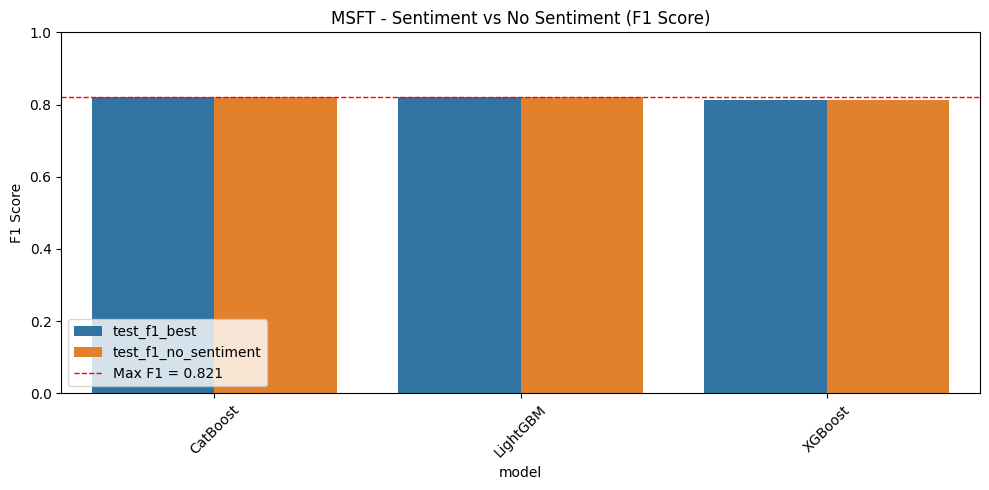

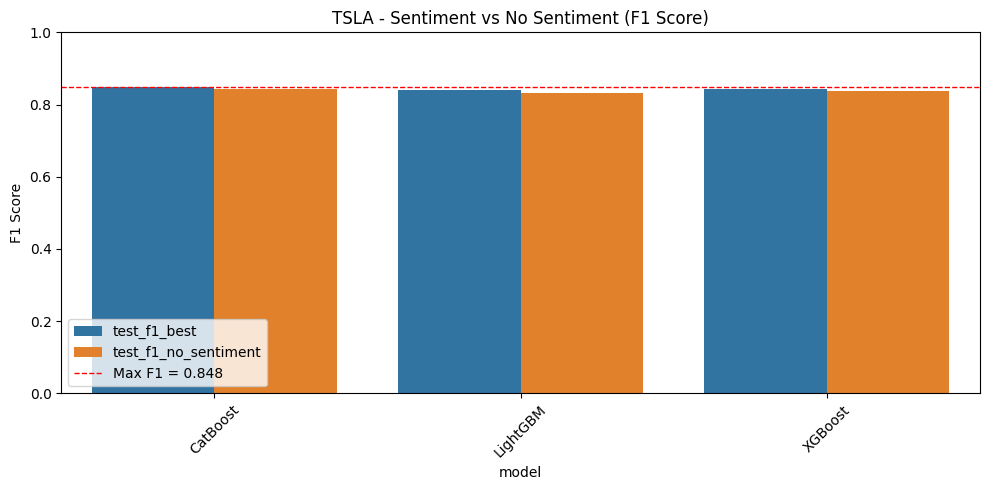

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Start with tuned results
# results_df = results_df_tuned.copy()
results_df = results_df_tuned[['ticker', 'feature_set','model','val_acc','test_acc', 'val_f1', 'test_f1']]

# Step 1: Keep only models that use sentiment
with_sentiment = results_df[~results_df['feature_set'].str.endswith('no_sentiment')]

# Step 2: Best (highest test_f1) per (ticker, model)
best_results = (
    with_sentiment
    .groupby(['ticker', 'model'], as_index=False)
    .apply(lambda g: g.loc[g['test_f1'].idxmax()], include_groups=False)
    .reset_index(drop=True)
)

# Step 3: Get corresponding no_sentiment results
no_sentiment = results_df[results_df['feature_set'].str.endswith('no_sentiment')]

# Step 4: Merge to compare sentiment vs no-sentiment
comparison_df = pd.merge(
    best_results,
    no_sentiment,
    on=['ticker', 'model'],
    suffixes=('_best', '_no_sentiment')
)

# Step 5: Calculate improvements
comparison_df['accuracy_improvement'] = comparison_df['test_acc_best'] - comparison_df['test_acc_no_sentiment']
comparison_df['f1_improvement'] = comparison_df['test_f1_best'] - comparison_df['test_f1_no_sentiment']

# Optional display settings
pd.set_option('display.max_rows', 160)
pd.set_option('display.max_columns', None)

# Output columns of interest
cols = [
    'ticker', 'model',
    'feature_set_best', 'test_acc_best', 'test_f1_best',
    'feature_set_no_sentiment', 'test_acc_no_sentiment', 'test_f1_no_sentiment',
    'accuracy_improvement', 'f1_improvement'
]

# Print per-ticker comparison tables
for ticker in comparison_df['ticker'].unique():
    print(f"\n--- Results for Ticker: {ticker} ---")
    df_sorted = comparison_df[comparison_df['ticker'] == ticker].sort_values(by='f1_improvement', ascending=False)
    print(df_sorted[cols].to_string(index=False))

# Plot comparison barplots
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker]

    plt.figure(figsize=(10, 5))
    df_melted = df_ticker.melt(
        id_vars='model',
        value_vars=['test_f1_best', 'test_f1_no_sentiment'],
        var_name='Feature Set',
        value_name='F1 Score'
    )

    sns.barplot(x='model', y='F1 Score', hue='Feature Set', data=df_melted)

    max_f1 = df_melted['F1 Score'].max()
    plt.axhline(max_f1, color='red', linestyle='--', linewidth=1, label=f'Max F1 = {max_f1:.3f}')
    plt.legend()

    plt.title(f"{ticker} - Sentiment vs No Sentiment (F1 Score)")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()




**Paired t-test: Evaluating Sentiment Impact**

This code statistically compares model performance with and without sentiment features using a **paired t-test** for each model:

* For each model (e.g., XGBoost, LightGBM, etc.), it extracts test F1-scores:

  * One with `open_sentiment_weighted` features.
  * One with `open_no_sentiment` features.
* Performs a **paired t-test** (`ttest_rel`) to test if differences in F1-scores are statistically significant.
* Outputs the **t-statistic** and **p-value** for each model.

A **low p-value** (typically < 0.05) suggests that incorporating sentiment features leads to a **statistically significant improvement**.


In [65]:
from scipy.stats import ttest_rel
import pandas as pd

# Load your results
# results_df = pd.read_csv("results_df.csv")

# Get all models
all_models = results_df['model'].unique()

print("Paired t-test results (Weighted Sentiment vs No Sentiment)\n")
print(f"{'Model':<25} {'T-stat':>8} {'P-value':>10}")
print("-" * 45)

for model in all_models:
    weighted = results_df.query(f"feature_set == 'open_sentiment_weighted' and model == '{model}'")['test_f1']
    no_sent  = results_df.query(f"feature_set == 'open_no_sentiment' and model == '{model}'")['test_f1']

    if len(weighted) == len(no_sent) and len(weighted) > 1:
        t_stat, p_val = ttest_rel(weighted, no_sent)
        print(f"{model:<25} {t_stat:>8.4f} {p_val:>10.4f}")
    else:
        print(f"{model:<25} {'--':>8} {'(insufficient)'}")


Paired t-test results (Weighted Sentiment vs No Sentiment)

Model                       T-stat    P-value
---------------------------------------------
XGBoost                     1.2834     0.2556
LightGBM                    0.2363     0.8226
CatBoost                    1.5957     0.1715


### **Paired t-test Summary: Does Sentiment Help?**

The paired t-tests compared **test F1-scores** between models trained with **weighted sentiment features** and those without sentiment features.

| Model    | T-stat | P-value | Interpretation             |
| -------- | ------ | ------- | -------------------------- |
| XGBoost  | 1.2834 | 0.2556  | No significant improvement |
| LightGBM | 0.2363 | 0.8226  | No significant improvement |
| CatBoost | 1.5957 | 0.1715  | No significant improvement |

---

### What This Means:

* All p-values are **greater than 0.05**, indicating that the observed differences in F1-scores between models with and without sentiment features are **not statistically significant**.
* While models like CatBoost and XGBoost showed slightly higher average F1-scores when using sentiment, these improvements were **not large enough to rule out random chance**.
* The results suggest that, under the current setup, adding sentiment features does **not consistently lead to significant performance gains** across models.
* This does not necessarily imply that sentiment features are irrelevant but highlights that **further refinement of sentiment integration (e.g., better weighting schemes, different time alignments, or filtering noise) may be necessary** to unlock their predictive power.




###  Ensemble Voting for Stock Prediction

This code evaluates an ensemble of three models (**XGBoost**, **LightGBM**, and **CatBoost**) using **soft voting**:

1. **For each stock ticker** and **feature set**:

   * Load test data from 2019.
   * Standardize the features.

2. **Load pre-trained models** (`joblib`) for each ticker-feature set.

3. **Get class probabilities** from all three models using `.predict_proba`.

4. **Average the probabilities** (soft voting) to generate final predictions.

5. **Evaluate predictions** using `classification_report` (accuracy and weighted F1).

6. **Save results** in `ensemble_results_df` for comparison across models and feature sets.




In [66]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

ensemble_results = []

for ticker in df['ticker_symbol'].unique():
    df_ticker = df[df['ticker_symbol'] == ticker].copy().sort_values('date')
    test = df_ticker[(df_ticker['date'] >= '2019-01-01') & (df_ticker['date'] <= '2019-12-31')]

    for feat_name, feat_cols in feature_sets.items():
        if len(test) < 50:
            continue

        X_test = test[feat_cols]
        y_test = test[target_label]

        try:
            model_xgb = joblib.load(f"saved_models/{ticker}_XGBoost_{feat_name}.joblib")
            model_lgb = joblib.load(f"saved_models/{ticker}_LightGBM_{feat_name}.joblib")
            model_cat = joblib.load(f"saved_models/{ticker}_CatBoost_{feat_name}.joblib")
        except FileNotFoundError:
            continue

        # Scale features
        scaler = StandardScaler()
        X_test_scaled = scaler.fit_transform(X_test)

        # Get probabilities
        try:
            prob_xgb = model_xgb.predict_proba(X_test_scaled)
            prob_lgb = model_lgb.predict_proba(X_test_scaled)
            prob_cat = model_cat.predict_proba(X_test_scaled)
        except Exception as e:
            print(f"Error in predict_proba for {ticker}-{feat_name}: {e}")
            continue

        # Ensure all models return the same number of classes
        if not (prob_xgb.shape[1] == prob_lgb.shape[1] == prob_cat.shape[1]):
            print(f"Skipping {ticker}-{feat_name} due to mismatched output shapes.")
            continue

        # Average the probabilities (soft voting)
        avg_prob = (prob_xgb + prob_lgb + prob_cat) / 3
        y_pred = np.argmax(avg_prob, axis=1)

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        ensemble_results.append({
            'ticker': ticker,
            'feature_set': feat_name,
            'ensemble_f1': report['weighted avg']['f1-score'],
            'ensemble_acc': report['accuracy']
        })

ensemble_results_df = pd.DataFrame(ensemble_results)


/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/shokoufehnaseri/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/utils/valida


--- Ensemble Comparison for Ticker: AAPL ---
ticker        feature_set_best  ensemble_f1_best  ensemble_acc_best feature_set_no_sentiment  ensemble_f1_no_sentiment  ensemble_acc_no_sentiment  f1_improvement  acc_improvement
  AAPL open_sentiment_weighted          0.786413           0.784861        open_no_sentiment                   0.77031                   0.768924        0.016103         0.015936

--- Ensemble Comparison for Ticker: AMZN ---
ticker        feature_set_best  ensemble_f1_best  ensemble_acc_best feature_set_no_sentiment  ensemble_f1_no_sentiment  ensemble_acc_no_sentiment  f1_improvement  acc_improvement
  AMZN open_sentiment_weighted          0.832332           0.832669        open_no_sentiment                  0.828263                   0.828685        0.004069         0.003984

--- Ensemble Comparison for Ticker: GOOG ---
ticker     feature_set_best  ensemble_f1_best  ensemble_acc_best feature_set_no_sentiment  ensemble_f1_no_sentiment  ensemble_acc_no_sentiment  f1

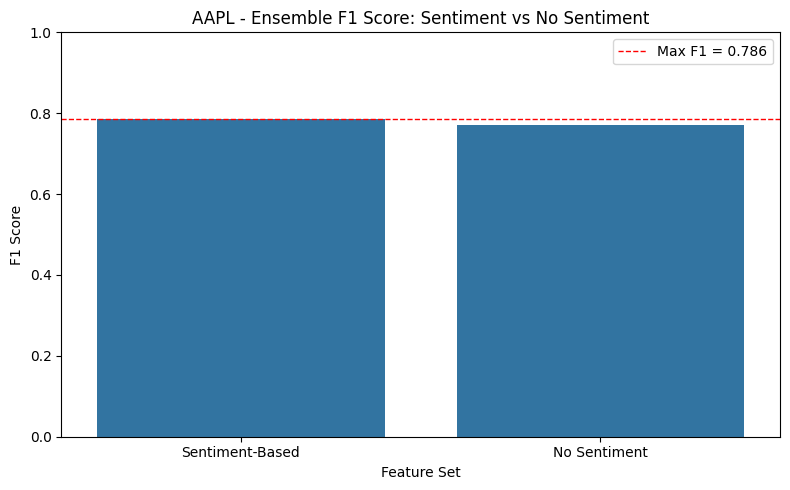

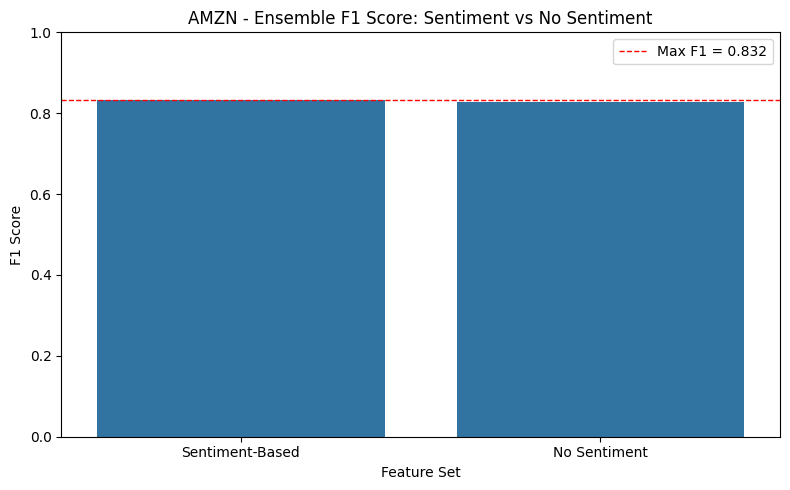

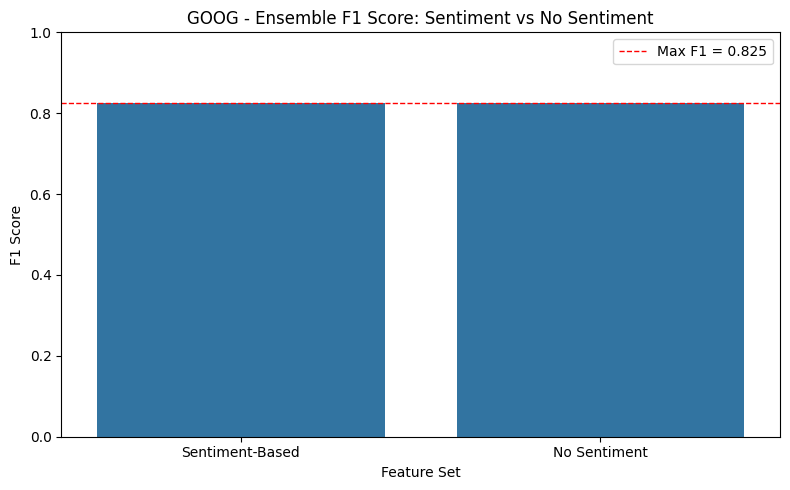

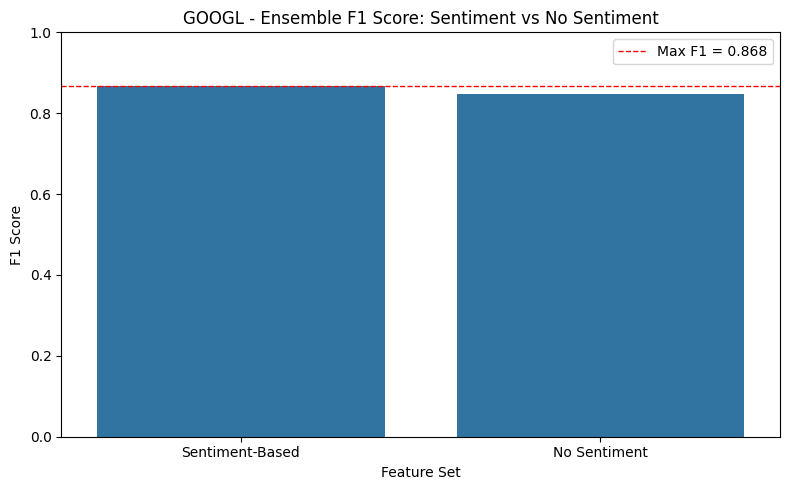

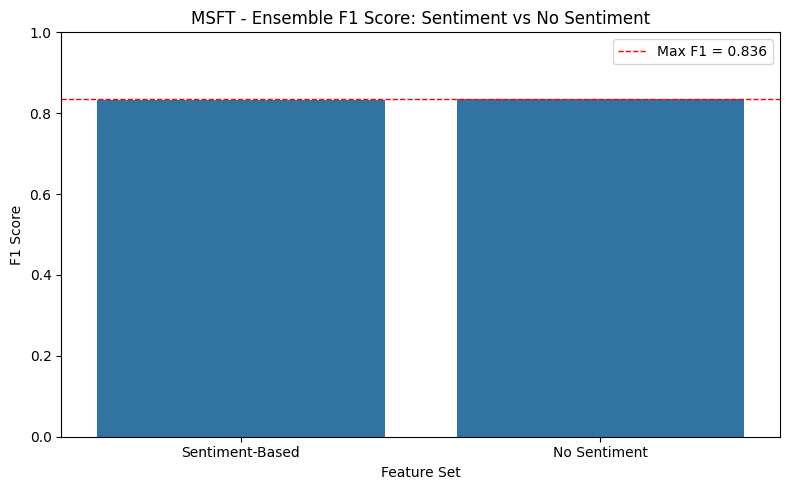

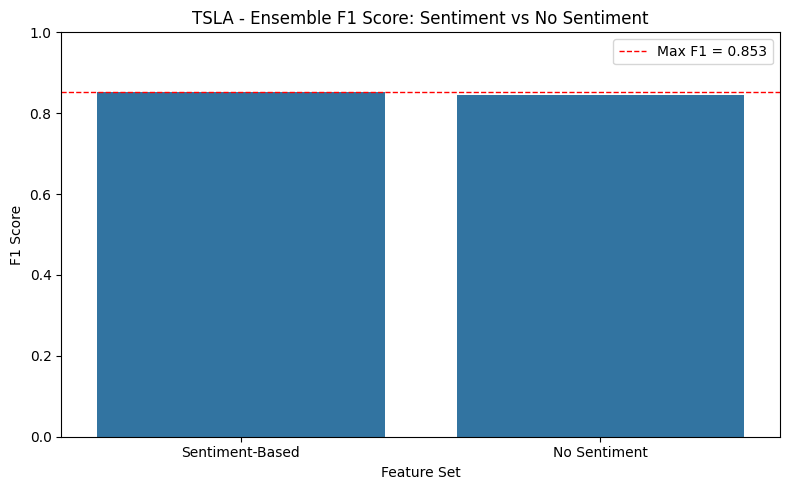

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter only sentiment-based models (not ending in 'no_sentiment')
with_sentiment = ensemble_results_df[~ensemble_results_df['feature_set'].str.endswith('no_sentiment')]

# Step 2: For each (ticker), get best sentiment-based feature set (highest F1)
best_results = (
    with_sentiment
    .groupby(['ticker'], as_index=False)
    .apply(lambda g: g.loc[g['ensemble_f1'].idxmax()], include_groups=False)
    .reset_index(drop=True)
)

# Step 3: Get no_sentiment counterparts
no_sentiment = ensemble_results_df[ensemble_results_df['feature_set'].str.endswith('no_sentiment')]

# Step 4: Merge best sentiment results with no_sentiment results
comparison_df = pd.merge(
    best_results,
    no_sentiment,
    on=['ticker'],
    suffixes=('_best', '_no_sentiment')
)

# Step 5: Calculate improvements
comparison_df['f1_improvement'] = comparison_df['ensemble_f1_best'] - comparison_df['ensemble_f1_no_sentiment']
comparison_df['acc_improvement'] = comparison_df['ensemble_acc_best'] - comparison_df['ensemble_acc_no_sentiment']

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Display
cols = [
    'ticker', 
    'feature_set_best', 'ensemble_f1_best', 'ensemble_acc_best',
    'feature_set_no_sentiment', 'ensemble_f1_no_sentiment', 'ensemble_acc_no_sentiment',
    'f1_improvement', 'acc_improvement'
]

for ticker in comparison_df['ticker'].unique():
    print(f"\n--- Ensemble Comparison for Ticker: {ticker} ---")
    df_t = comparison_df[comparison_df['ticker'] == ticker]
    print(df_t[cols].to_string(index=False))

# Plot
for ticker in comparison_df['ticker'].unique():
    df_ticker = comparison_df[comparison_df['ticker'] == ticker]

    plt.figure(figsize=(8, 5))
    df_plot = pd.DataFrame({
        'Feature Set': ['Sentiment-Based', 'No Sentiment'],
        'F1 Score': [
            df_ticker['ensemble_f1_best'].values[0],
            df_ticker['ensemble_f1_no_sentiment'].values[0]
        ]
    })

    sns.barplot(x='Feature Set', y='F1 Score', data=df_plot)
    max_f1 = df_plot['F1 Score'].max()
    plt.axhline(max_f1, color='red', linestyle='--', linewidth=1, label=f'Max F1 = {max_f1:.3f}')
    plt.title(f"{ticker} - Ensemble F1 Score: Sentiment vs No Sentiment")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()



### SHAP Value Summary (Bar Plot)
The SHAP bar plots show the average importance of each feature in predicting stock trend classes. Higher SHAP values indicate stronger influence. These visualizations help interpret which financial and sentiment features most contribute to model decisions across different tickers and feature sets.


SHAP Summary for AAPL - open_sentiment_basic


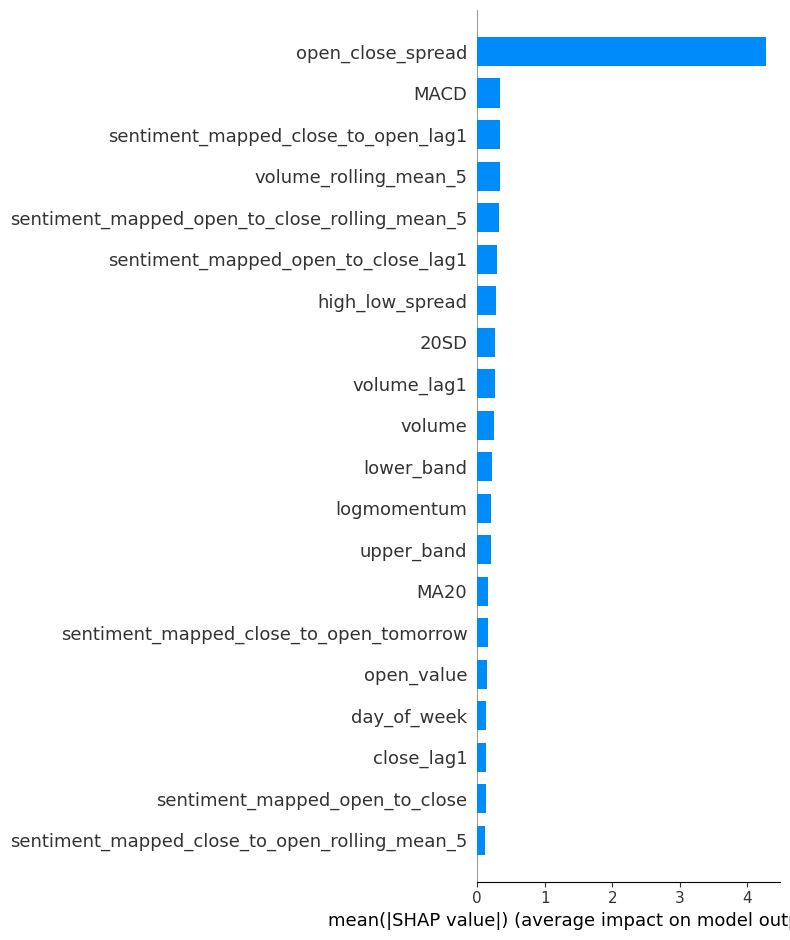


SHAP Summary for AAPL - open_sentiment_weighted


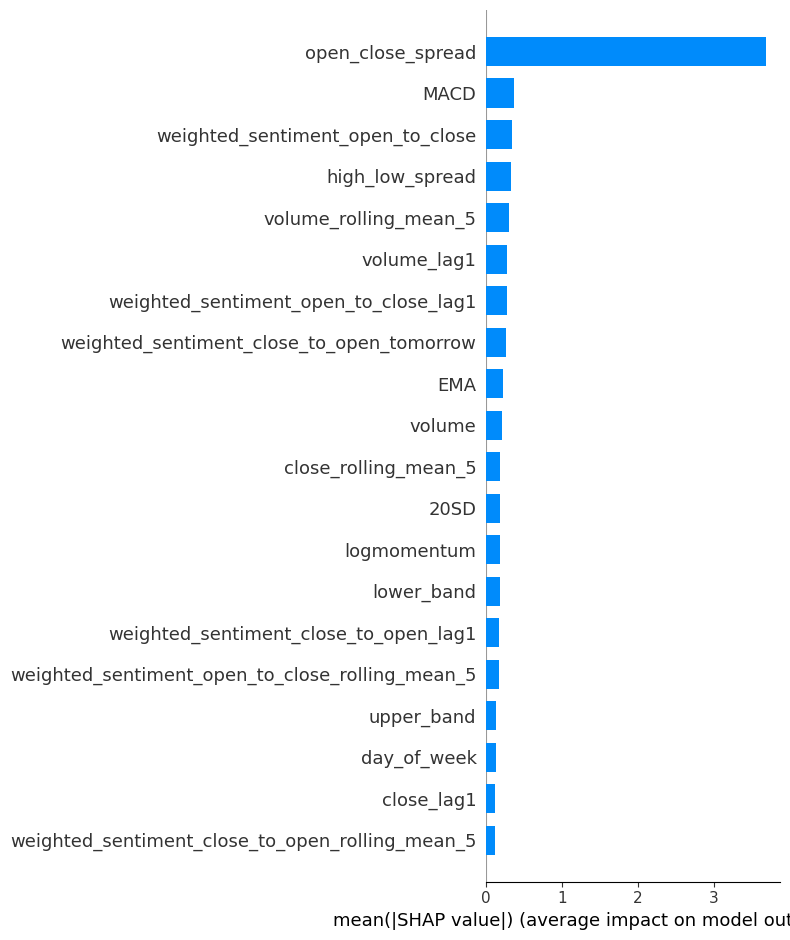


SHAP Summary for AAPL - open_no_sentiment


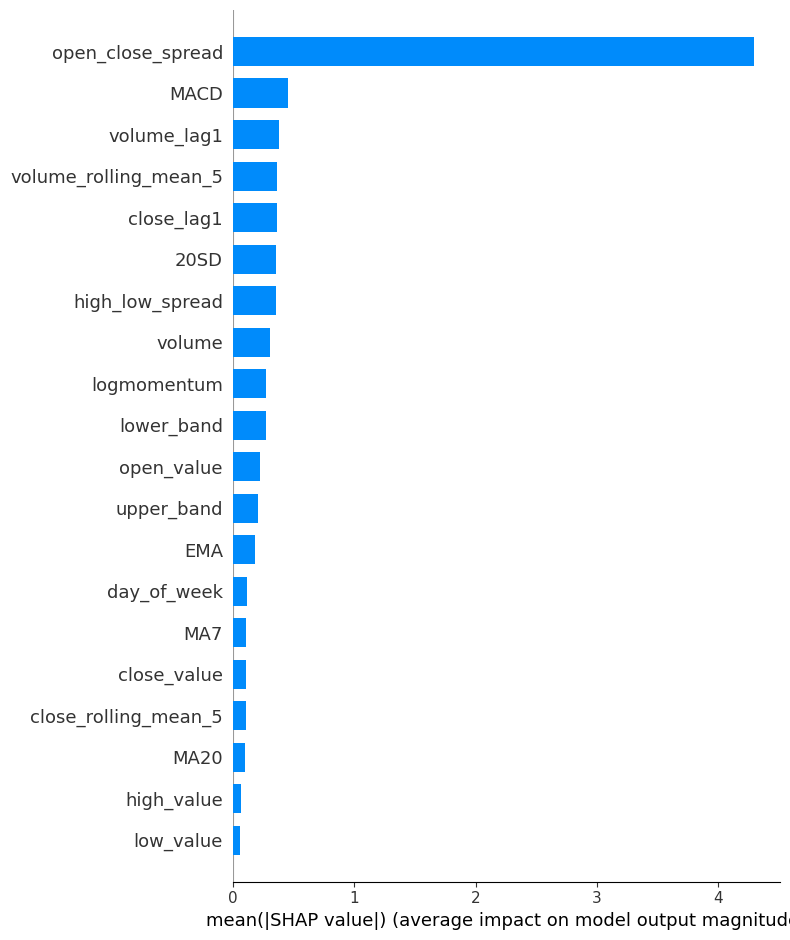


SHAP Summary for AMZN - open_sentiment_basic


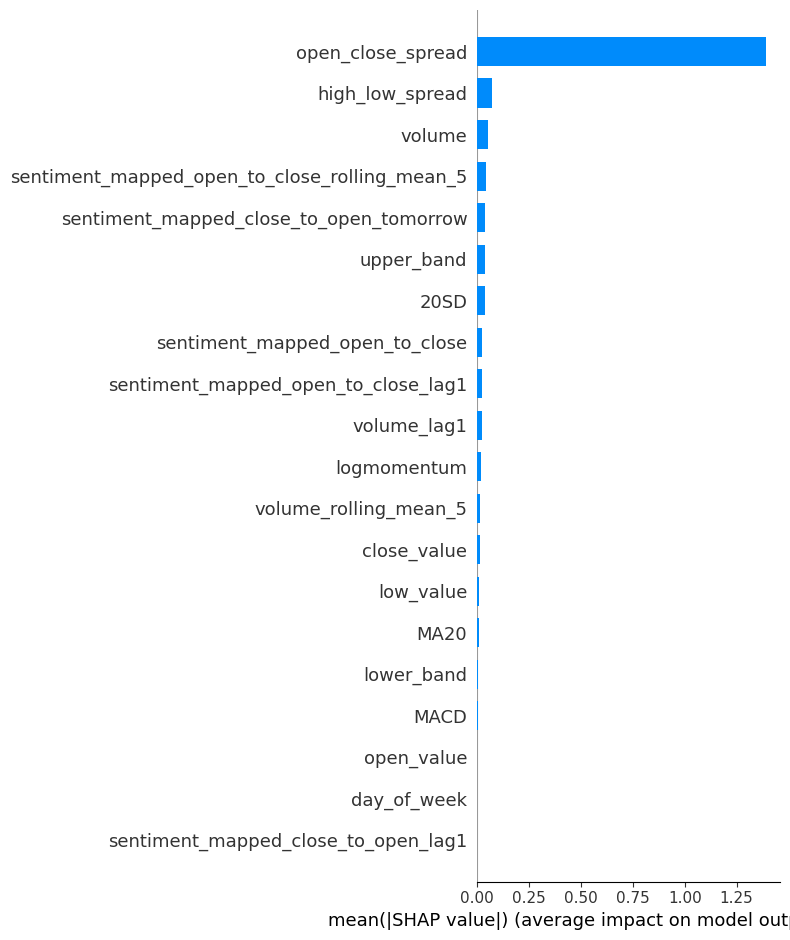


SHAP Summary for AMZN - open_sentiment_weighted


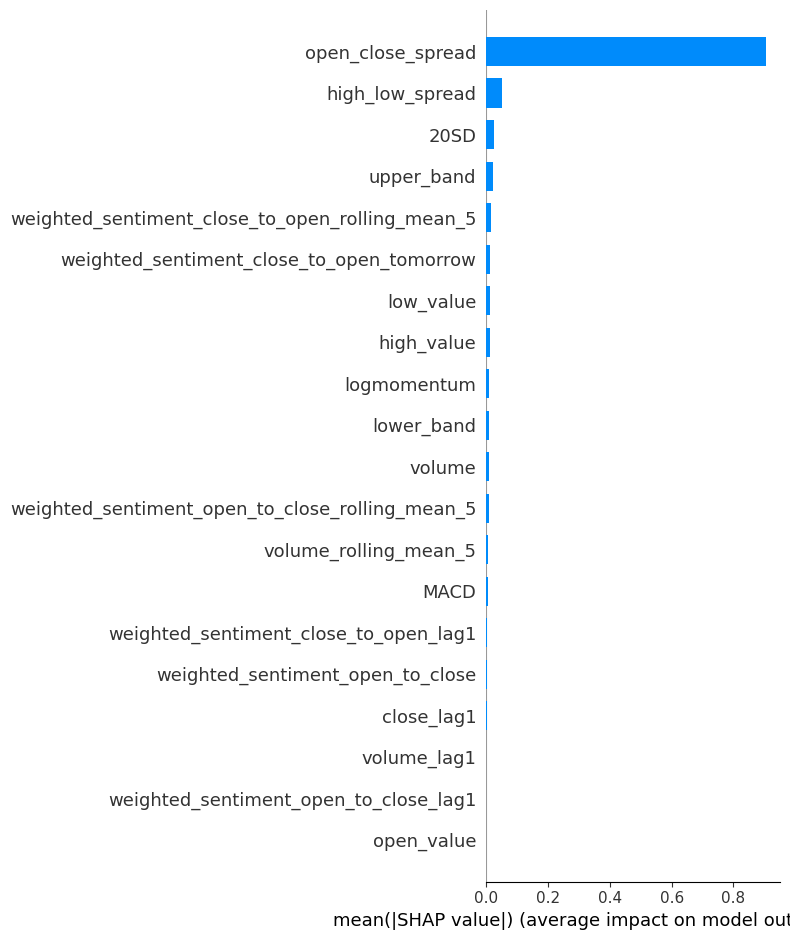


SHAP Summary for AMZN - open_no_sentiment


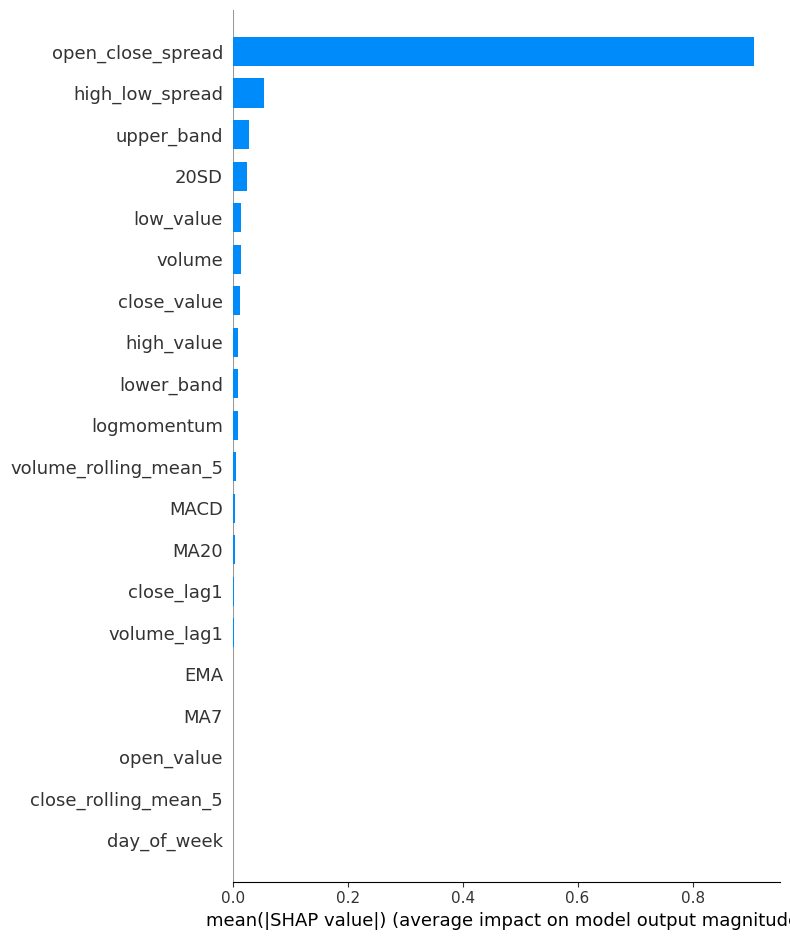


SHAP Summary for GOOG - open_sentiment_basic


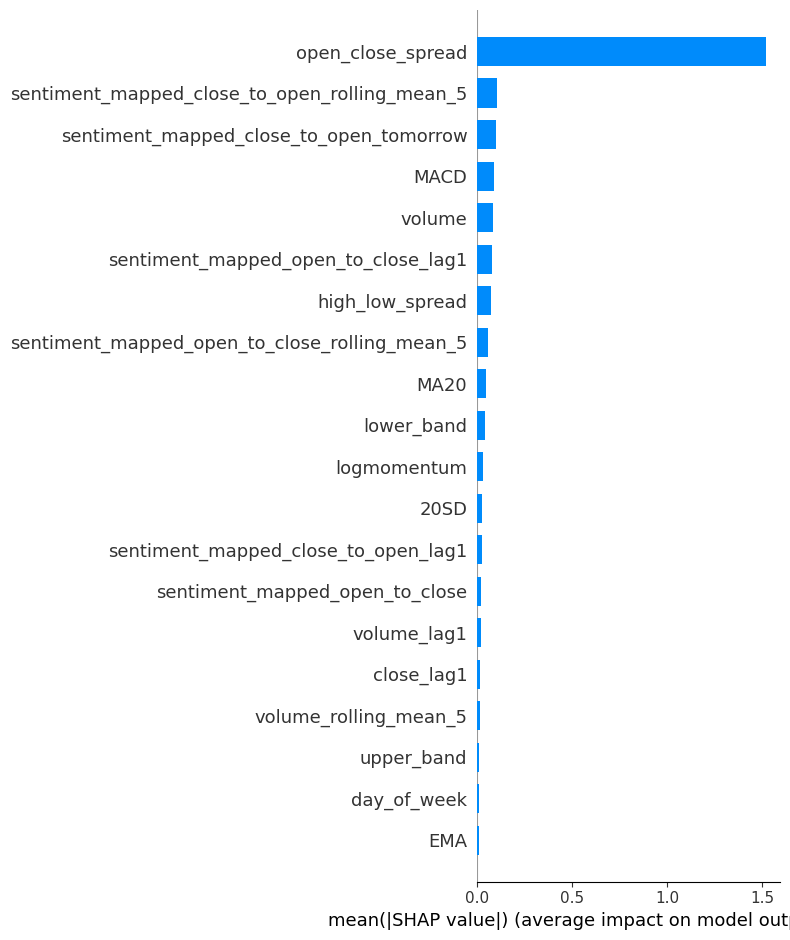


SHAP Summary for GOOG - open_sentiment_weighted


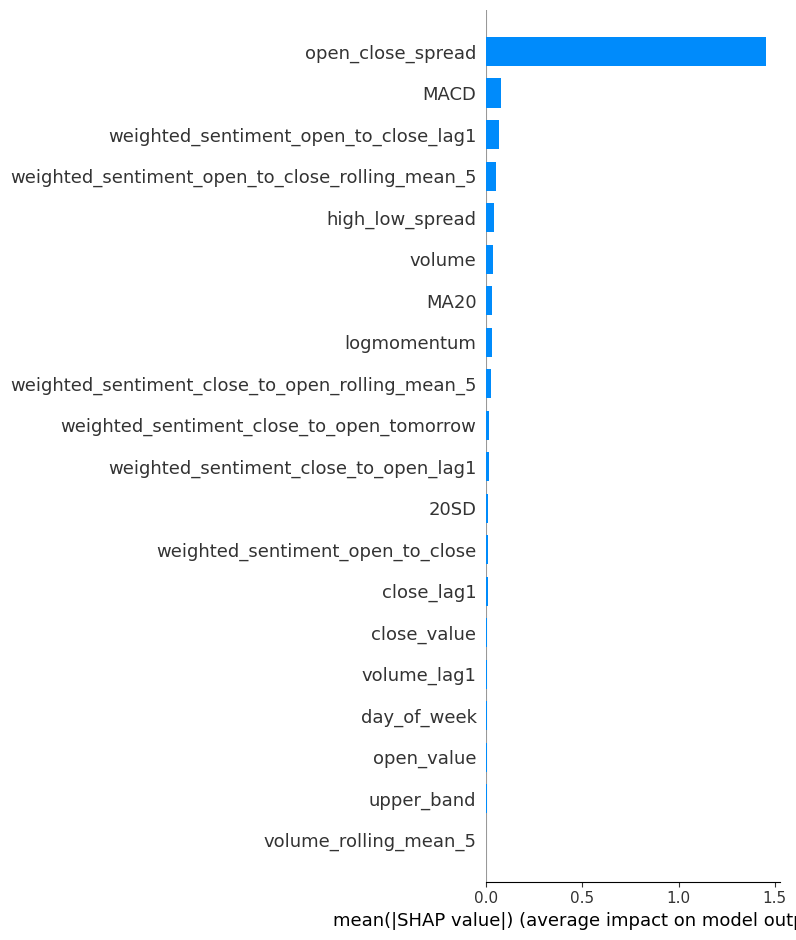


SHAP Summary for GOOG - open_no_sentiment


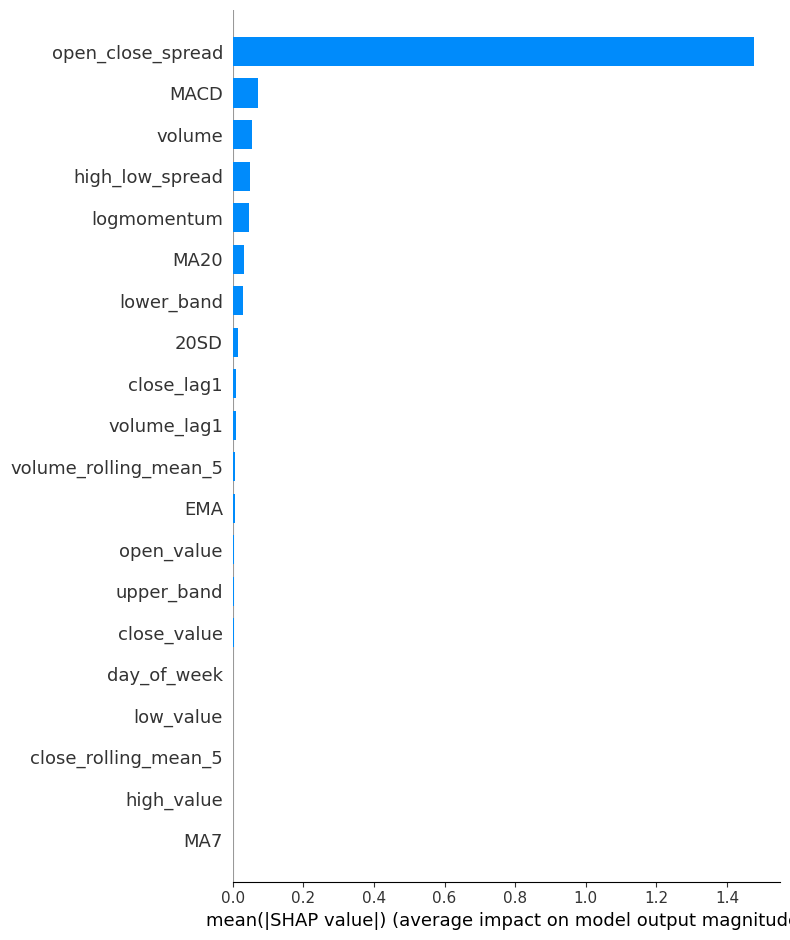


SHAP Summary for GOOGL - open_sentiment_basic


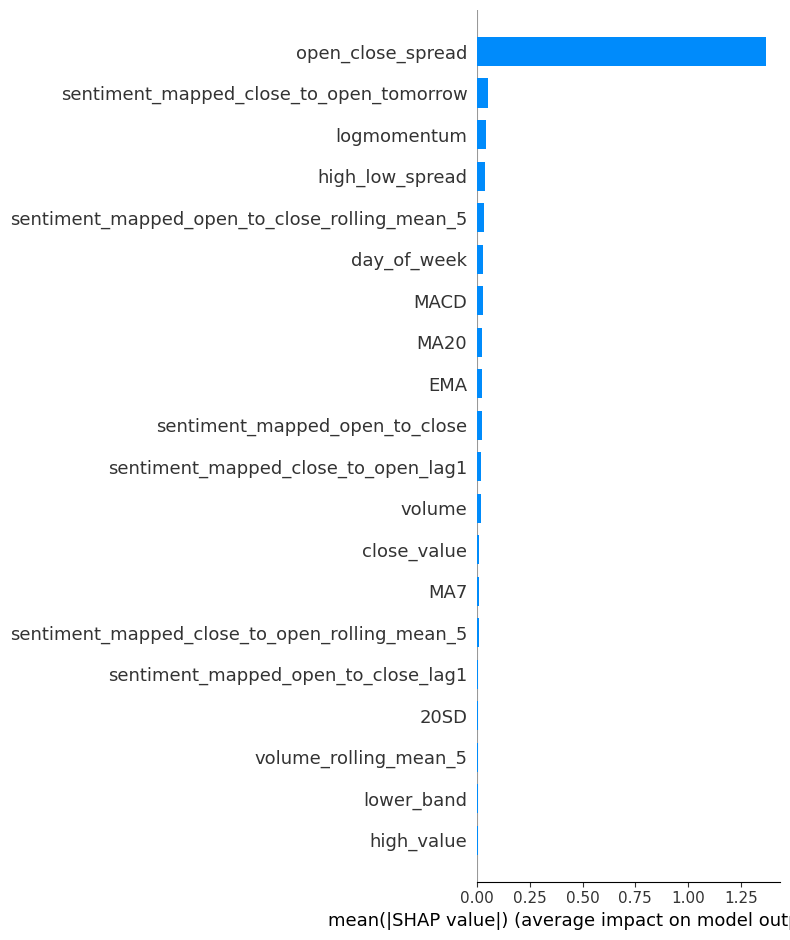


SHAP Summary for GOOGL - open_sentiment_weighted


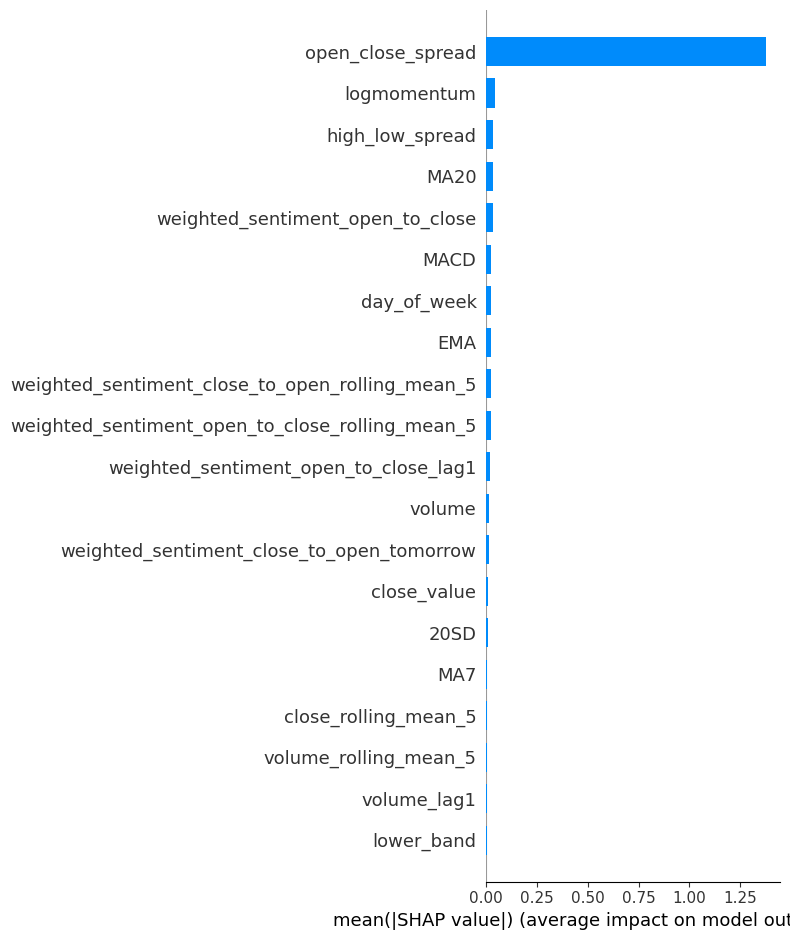


SHAP Summary for GOOGL - open_no_sentiment


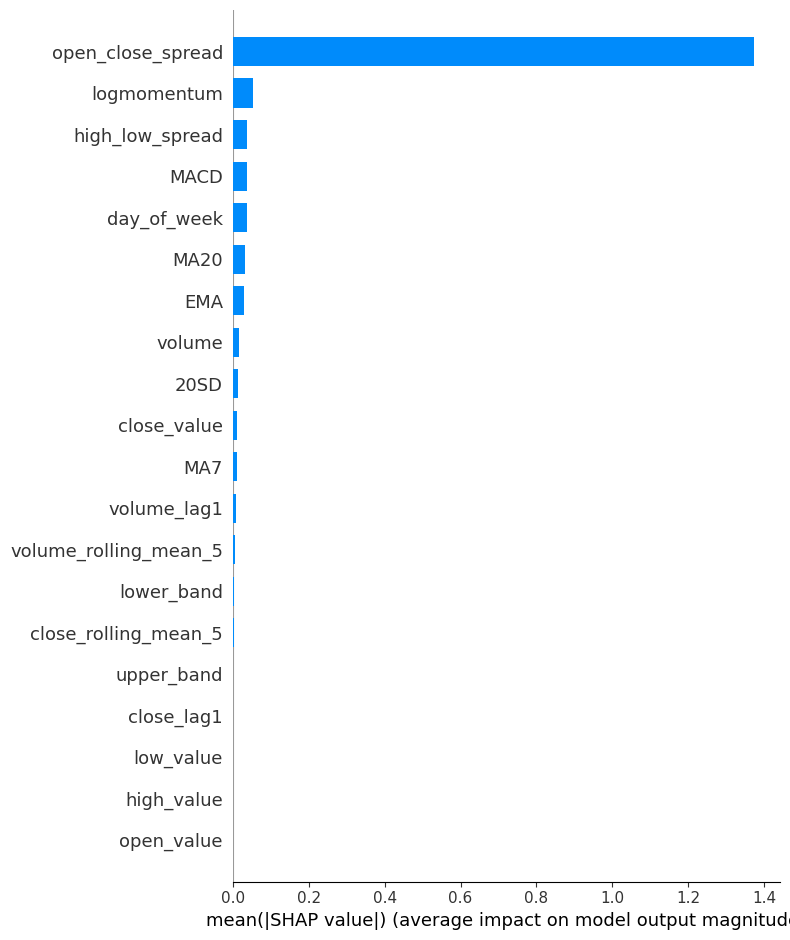


SHAP Summary for MSFT - open_sentiment_basic


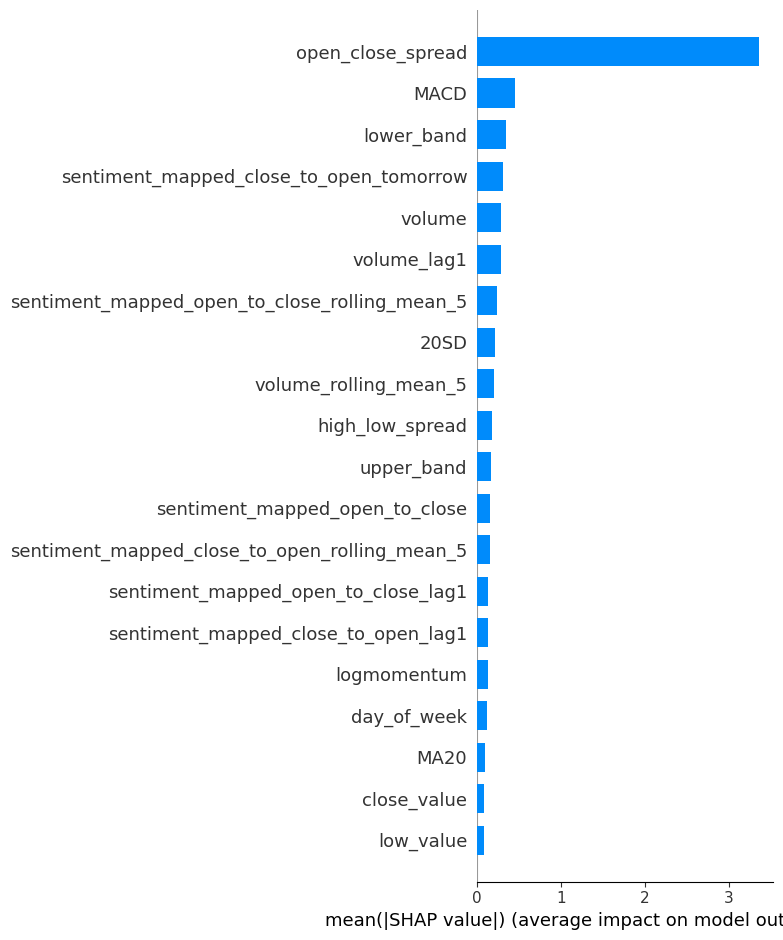


SHAP Summary for MSFT - open_sentiment_weighted


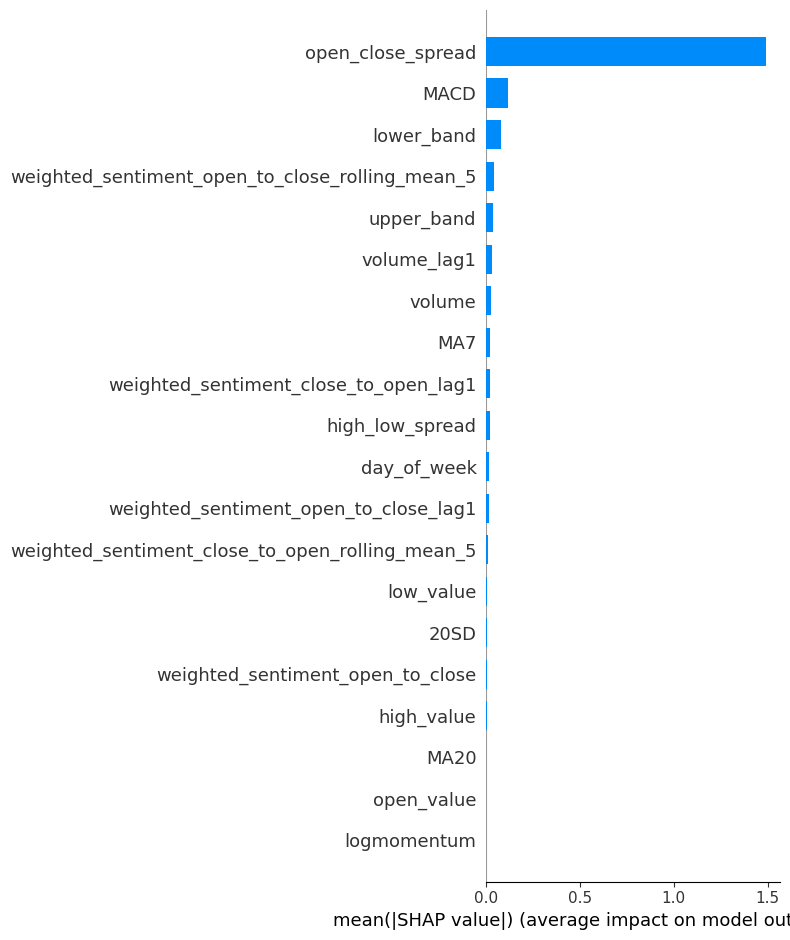


SHAP Summary for MSFT - open_no_sentiment


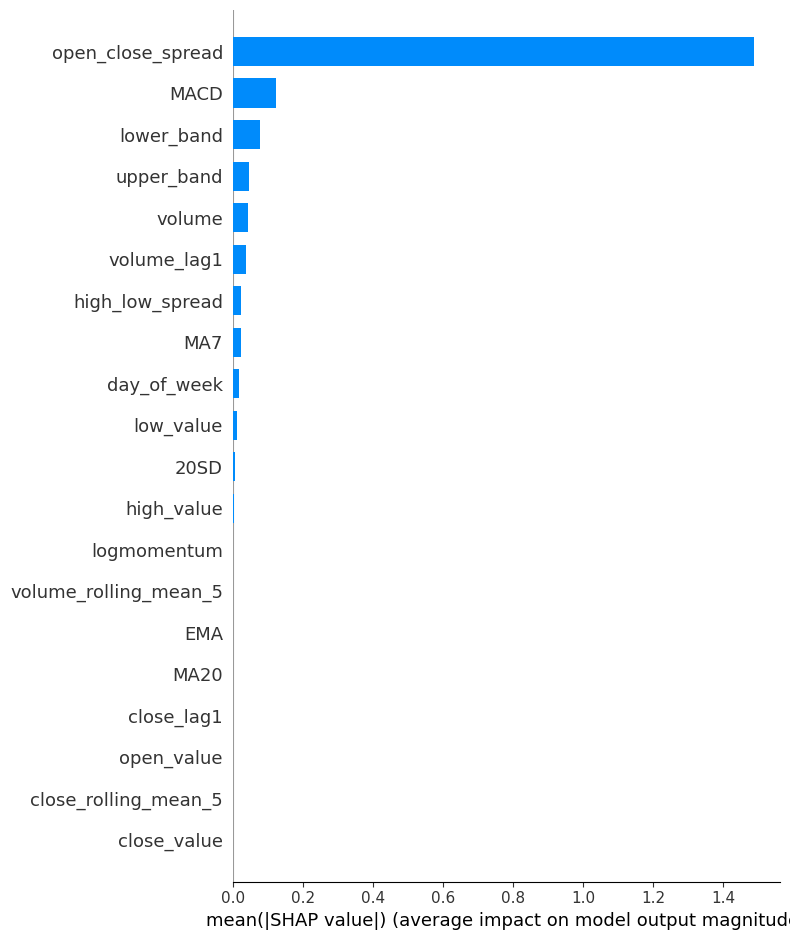


SHAP Summary for TSLA - open_sentiment_basic


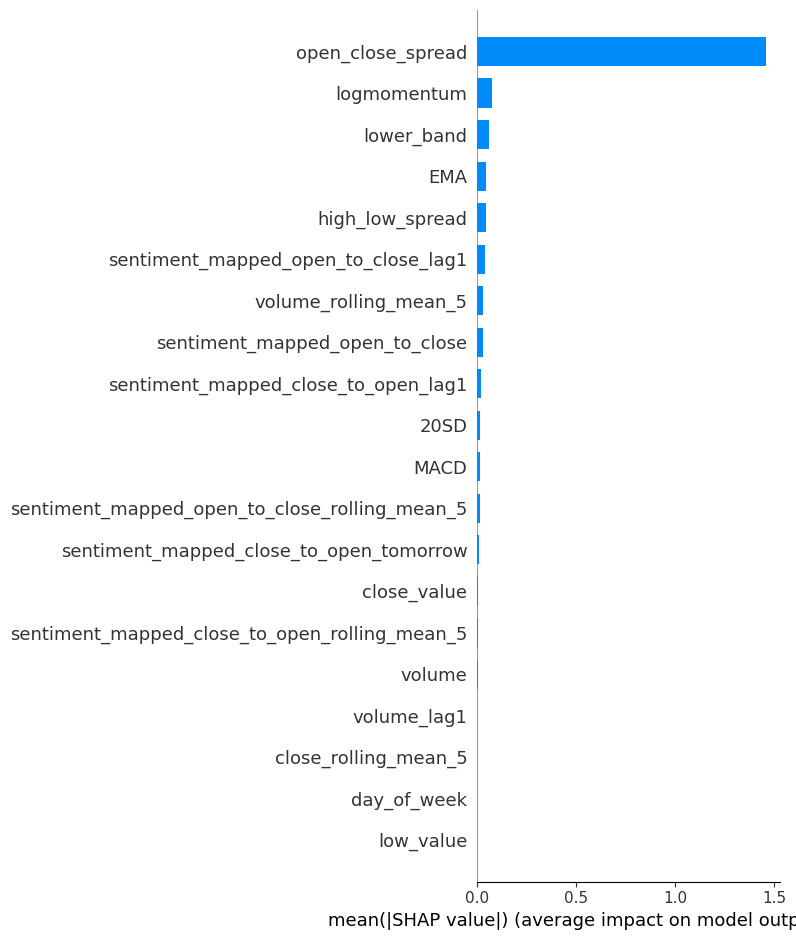


SHAP Summary for TSLA - open_sentiment_weighted


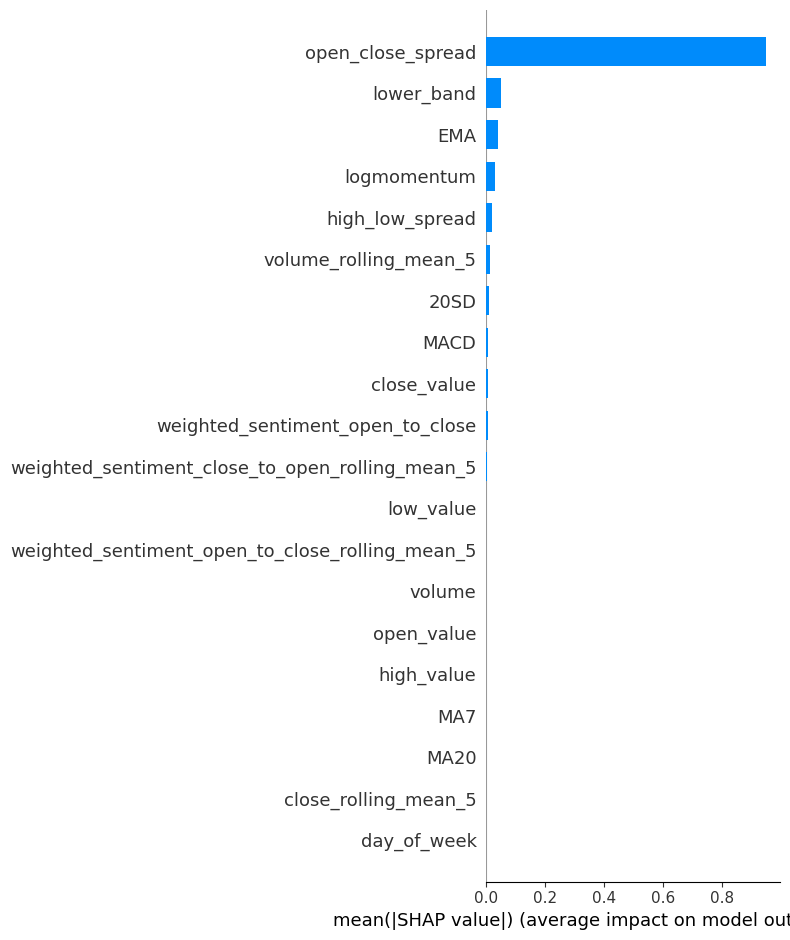


SHAP Summary for TSLA - open_no_sentiment


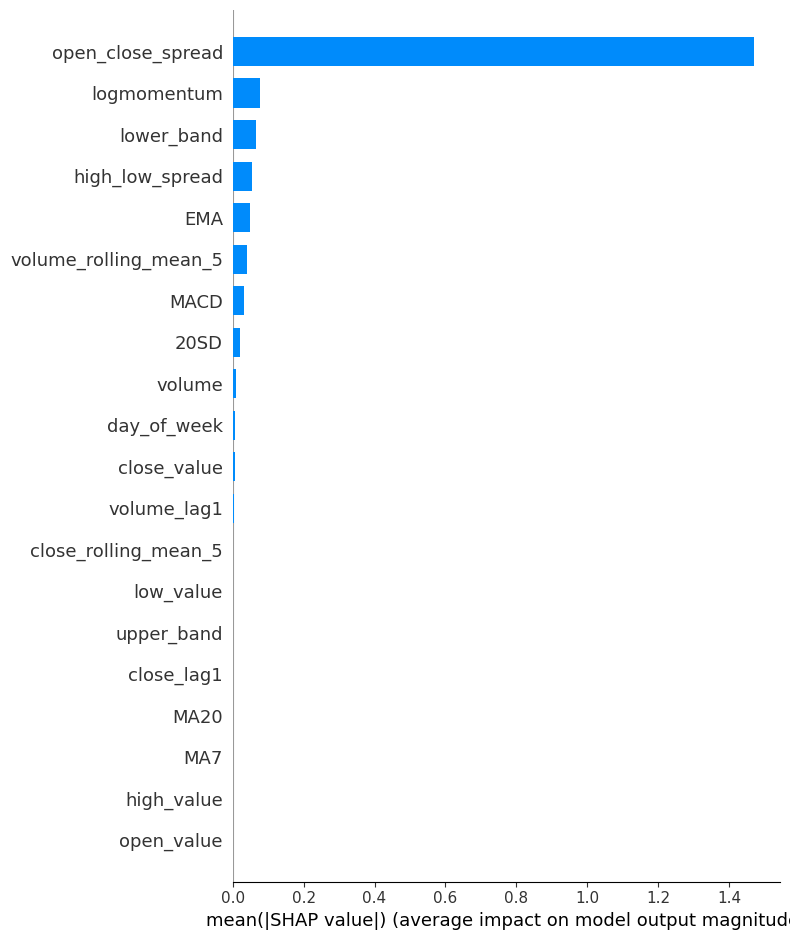

In [68]:
import shap
import matplotlib.pyplot as plt

for ticker in df['ticker_symbol'].unique():
    df_ticker = df[df['ticker_symbol'] == ticker].copy().sort_values('date')
    test = df_ticker[(df_ticker['date'] >= '2019-01-01') & (df_ticker['date'] <= '2019-12-31')]

    for feat_name, feat_cols in feature_sets.items():
        X_test = test[feat_cols]
        y_test = test[target_label]

        if len(test) < 50:
            continue

        try:
            model_xgb = joblib.load(f"saved_models/{ticker}_XGBoost_{feat_name}.joblib")
        except FileNotFoundError:
            print(f"Model not found: {ticker}_XGBoost_{feat_name}")
            continue

        # Standardize
        scaler = StandardScaler()
        X_test_scaled = scaler.fit_transform(X_test)

        # SHAP
        explainer = shap.Explainer(model_xgb)
        shap_values = explainer(X_test_scaled)

        print(f"\nSHAP Summary for {ticker} - {feat_name}")
        shap.summary_plot(shap_values, X_test, feature_names=feat_cols, plot_type="bar")
